In [1]:
import os
import pickle
import pathlib

import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import seaborn as sns
import pandas as pd
import pingouin as pg

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice


plt.rcParams['pdf.fonttype']=42
%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/figS8_novel_activity_rate')
figdir.mkdir(exist_ok=True, parents=True)

In [26]:
sess = u.load_single_day(ctrl_mice[8], 4)



{'date': '20_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 4}


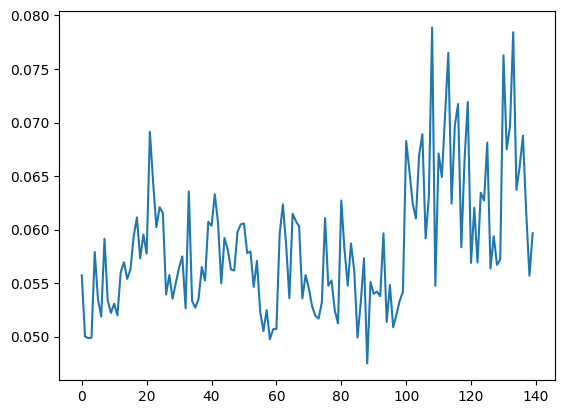

In [27]:
fig, ax = plt.subplots()
ax.plot(np.nanmean(np.nanmean(sess.trial_matrices['F_dff'],axis=1),axis=-1))

In [28]:
def plot_block_avg(block_rate, key='act', norm = 'population', max_trial=5):
    fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


    for day in np.arange(5):
        base = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan}
        fam = {'ctrl': np.zeros([len(ctrl_mice),max_trial])*np.nan, 'ko': np.zeros([len(ko_mice),max_trial])*np.nan}
        nov = {'ctrl': np.zeros([len(ctrl_mice),max_trial])*np.nan, 'ko': np.zeros([len(ko_mice),max_trial])*np.nan}

        for cond, mice in zip(('ctrl','ko'), (ctrl_mice, ko_mice)):
            for i, mouse in enumerate(mice):
                try:
                    data = block_rate.activity_rates[cond][mouse][day]
                except:
                    continue

                if norm is None:

                    if key == 'act':
                       
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[cond][i,:_base.shape[0]] = _base
                    fam[cond][i,:_fam.shape[0]] = _fam
                    nov[cond][i,:_nov.shape[0]] = _nov

                elif norm == 'population':
                    if key == 'act':
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[cond][i,:_base.shape[0]] = _base/_base.mean()
                    fam[cond][i,:_fam.shape[0]] = _fam/_base.mean()
                    nov[cond][i,:_nov.shape[0]] = _nov/_base.mean()
                elif norm == 'cell':
                    cell_denom = data['baseline_avg_act']

                    _base = np.nanmean(np.nanmean(data[f'baseline_{key}']/cell_denom,axis=1),axis=-1)
                    base[cond][i,:_base.shape[0]] = _base

                    _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}']/cell_denom,axis=1),axis=-1)[:max_trial]
                    fam[cond][i,:_fam.shape[0]] = _fam

                    _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}']/cell_denom,axis=1), axis=-1)[:max_trial]
                    nov[cond][i,:_nov.shape[0]] = _nov

        for cond, color in zip(('ctrl','ko'), ('black', 'red')):
            x_base = np.arange(-10,0)
            mu, sem = np.nanmean(base[cond], axis=0), sp.stats.sem(base[cond],axis=0, nan_policy='omit')
            ax[0,day].plot(x_base, mu, color=color)
            ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            ax[1,day].plot(x_base, mu, color=color)
            ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            x_block = np.arange(1,max_trial+1)
            mu, sem = np.nanmean(fam[cond], axis=0), sp.stats.sem(fam[cond],axis=0, nan_policy='omit')
            ax[0,day].plot(x_block, mu, color=color)
            ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
            ax[1,day].plot(x_block, mu, color=color)
            ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            ax[0,day].set_title(f'familiar: day {day}')
            ax[1,day].set_title(f'novel: day {day}')

    for a in ax.flatten():
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)
        if key == 'act':
            a.set_ylabel('activity rate (dF/F)')
        else:
            a.set_ylabel(key)
        a.set_xlabel('Trial')
    return fig, ax

4467331.1
4467331.2
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
4467332.1
4467332.2


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:73: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(trial_mat[baseline_trials,:,:],


30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
4467333.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


mCherry6
mCherry7
mCherry8
mCherry9
4467975.1


...

/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.3


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.4
4467975.5
Cre7
Cre9


/tmp/ipykernel_519232/1087830364.py:43: RuntimeWarning: Mean of empty slice.
  base[cond][i,:_base.shape[0]] = _base/_base.mean()
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_519232/1087830364.py:44: RuntimeWarning: Mean of empty slice.
  fam[cond][i,:_fam.shape[0]] = _fam/_base.mean()
/tmp/ipykernel_519232/1087830364.py:45: RuntimeWarning: Mean of empty slice.
  nov[cond][i,:_nov.shape[0]] = _nov/_base.mean()
/tmp/ipykernel_519232/1087830364.py:72: RuntimeWarning: Mean of empty slice
  mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
/tmp/ipykernel_519232/1087830364.py:72: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  mu,

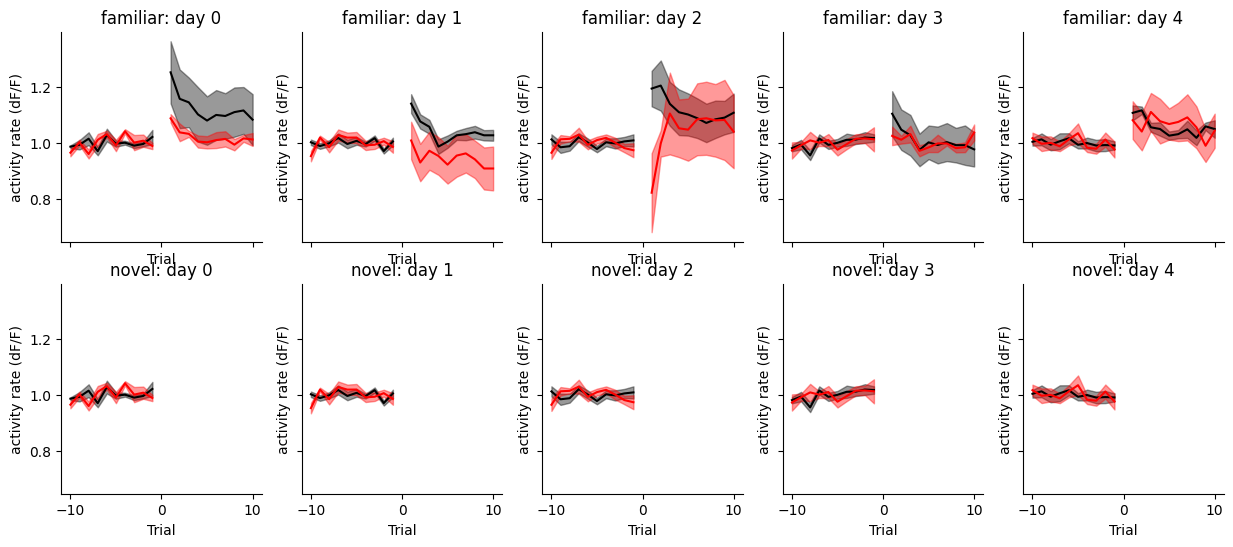

In [ ]:
block_rate = stx.novel_activity_rate.BlockTransitionActivityRate(ts_key='F_dff', block=2 )


/tmp/ipykernel_519232/1087830364.py:43: RuntimeWarning: Mean of empty slice.
  base[cond][i,:_base.shape[0]] = _base/_base.mean()
/tmp/ipykernel_519232/1087830364.py:44: RuntimeWarning: Mean of empty slice.
  fam[cond][i,:_fam.shape[0]] = _fam/_base.mean()
/tmp/ipykernel_519232/1087830364.py:45: RuntimeWarning: Mean of empty slice.
  nov[cond][i,:_nov.shape[0]] = _nov/_base.mean()
/tmp/ipykernel_519232/1087830364.py:72: RuntimeWarning: Mean of empty slice
  mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
/tmp/ipykernel_519232/1087830364.py:72: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
/tmp/ipykernel_519232/1087830364.py:68: SmallSampleWarning: After omitting NaNs, one or more axis-sl

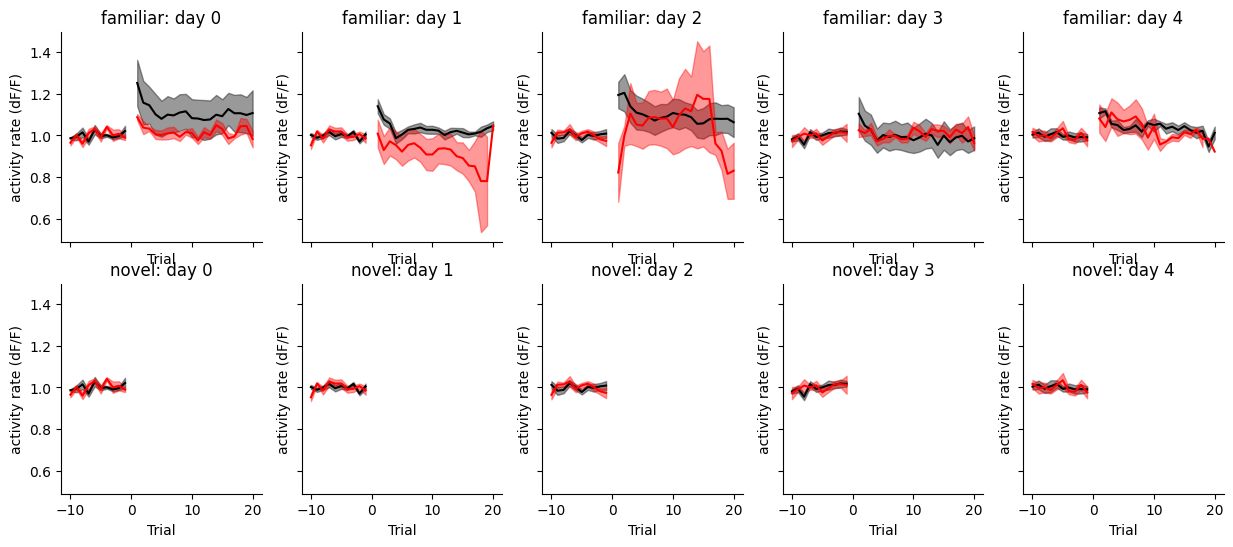

In [30]:
fig, ax = plot_block_avg(block_rate, key='act', norm = 'population', max_trial=20)

4467331.1
4467331.2
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
4467332.1
4467332.2
30_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
4467333.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")


mCherry6
mCherry7
mCherry8
mCherry9
4467975.1


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:73: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(trial_mat[baseline_trials,:,:],
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guar

4467975.2


...

4467975.2


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.3


/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
/home/mplitt/repos/TwoPUtils/TwoPUtils/sess.py:100: UserWarning: skipping checking keys,

4467975.4
4467975.5
Cre7
Cre9


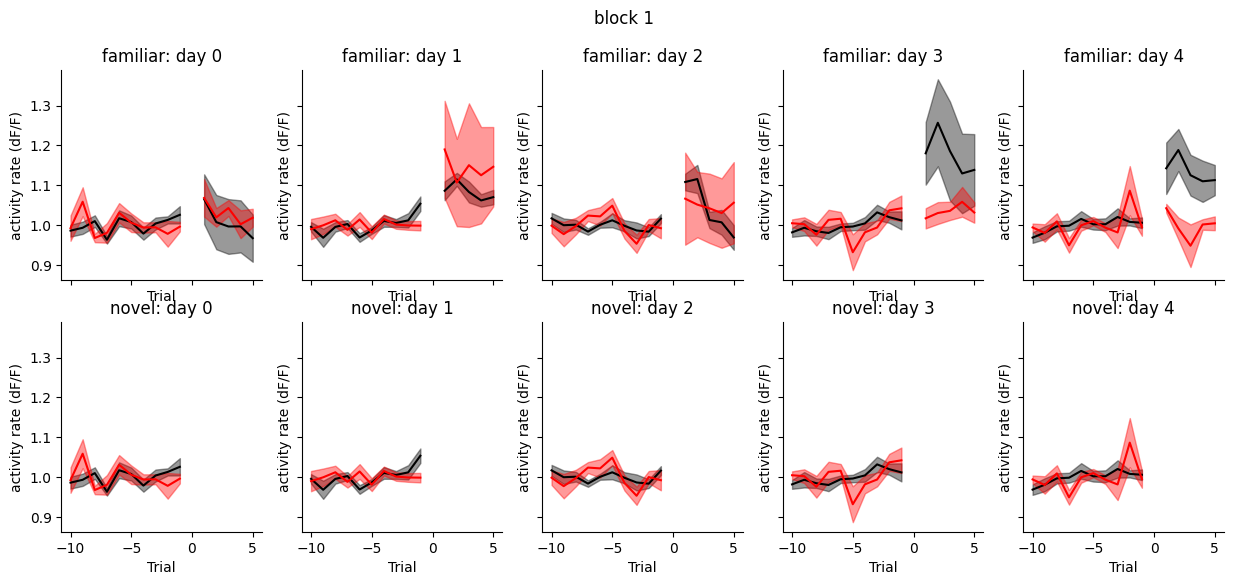

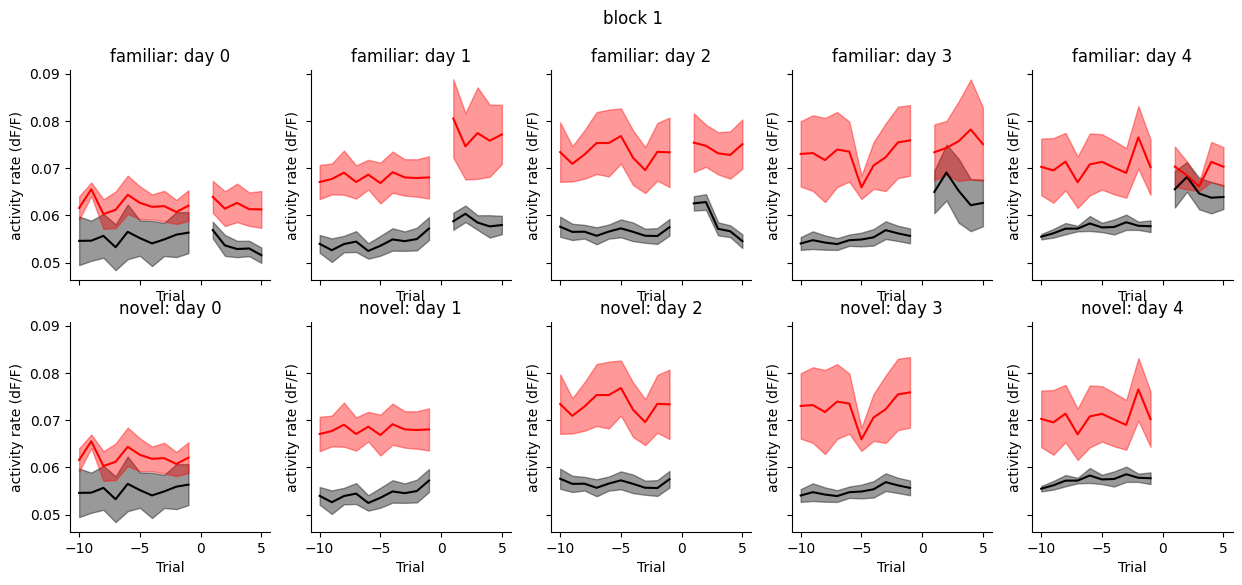

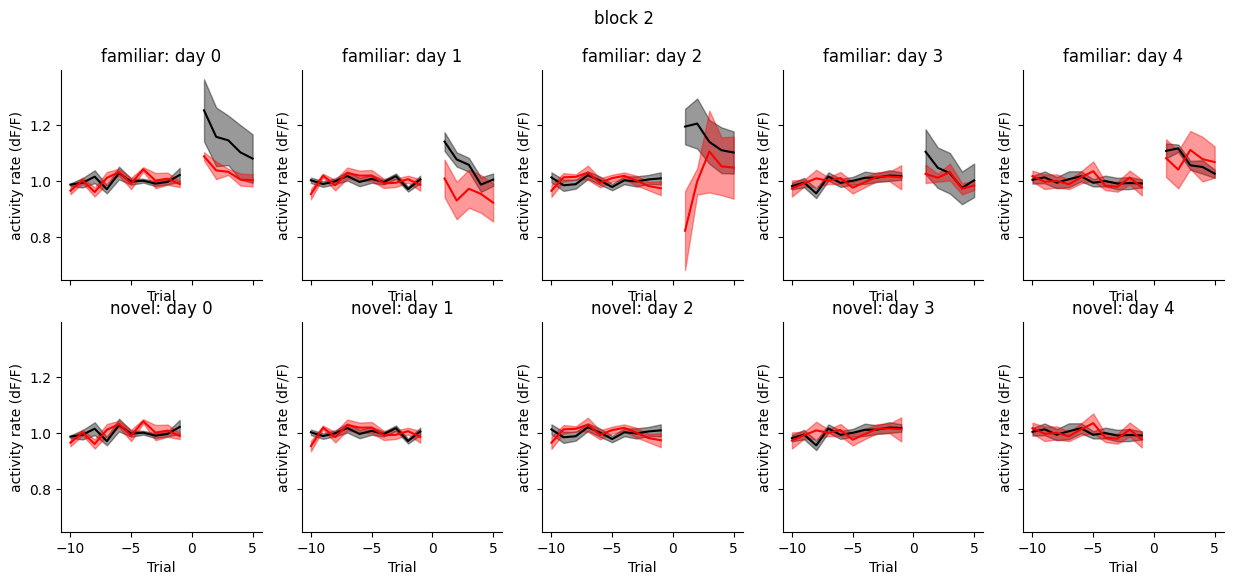

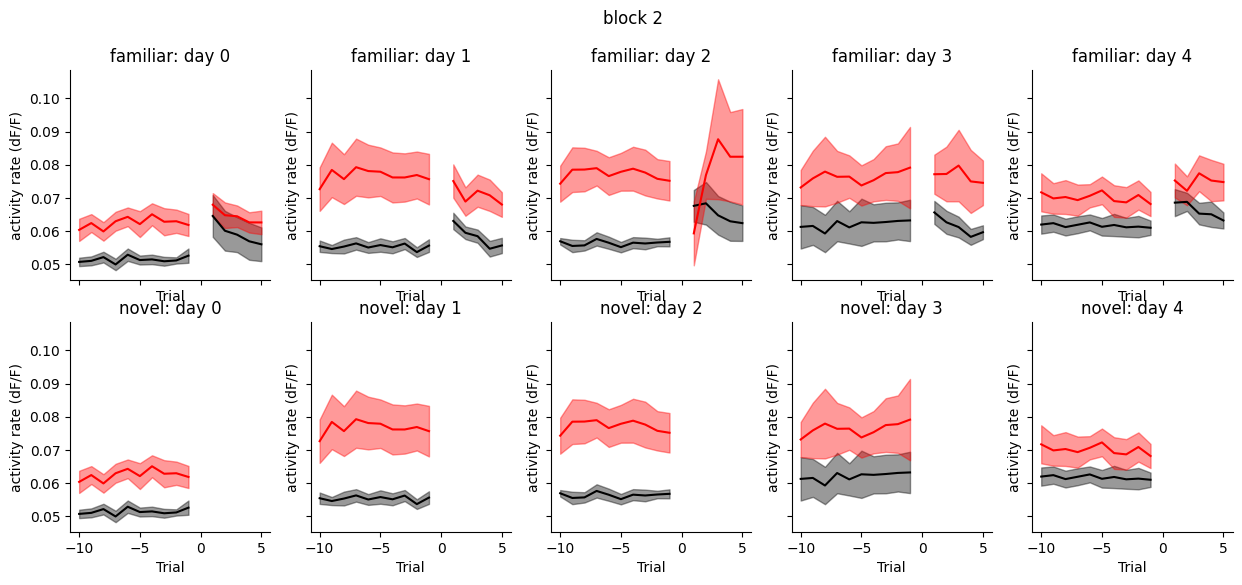

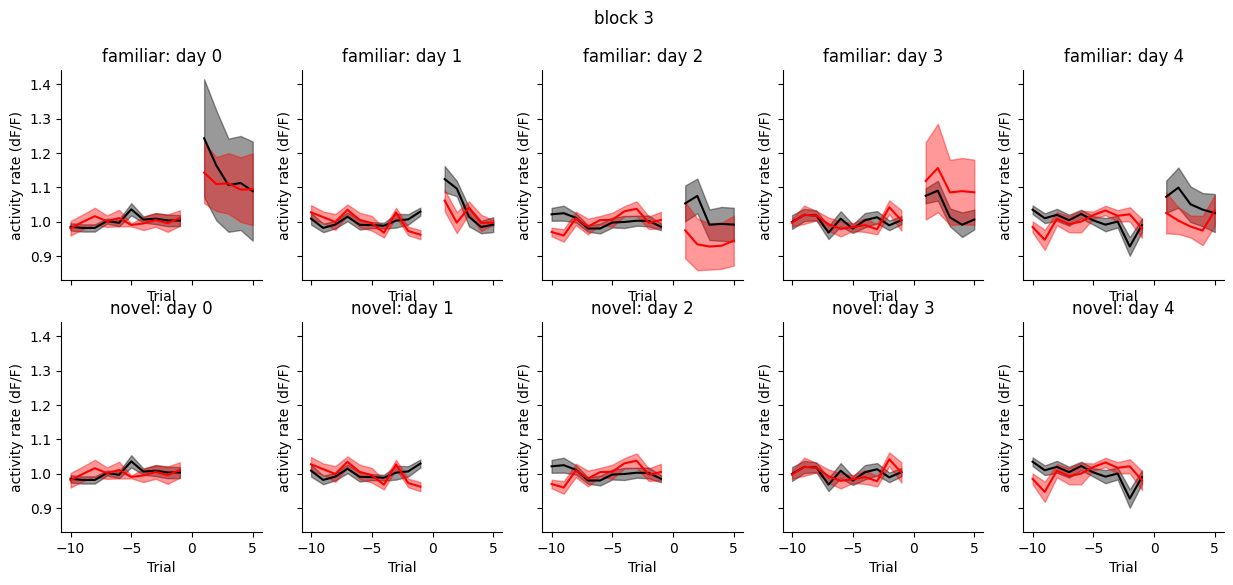

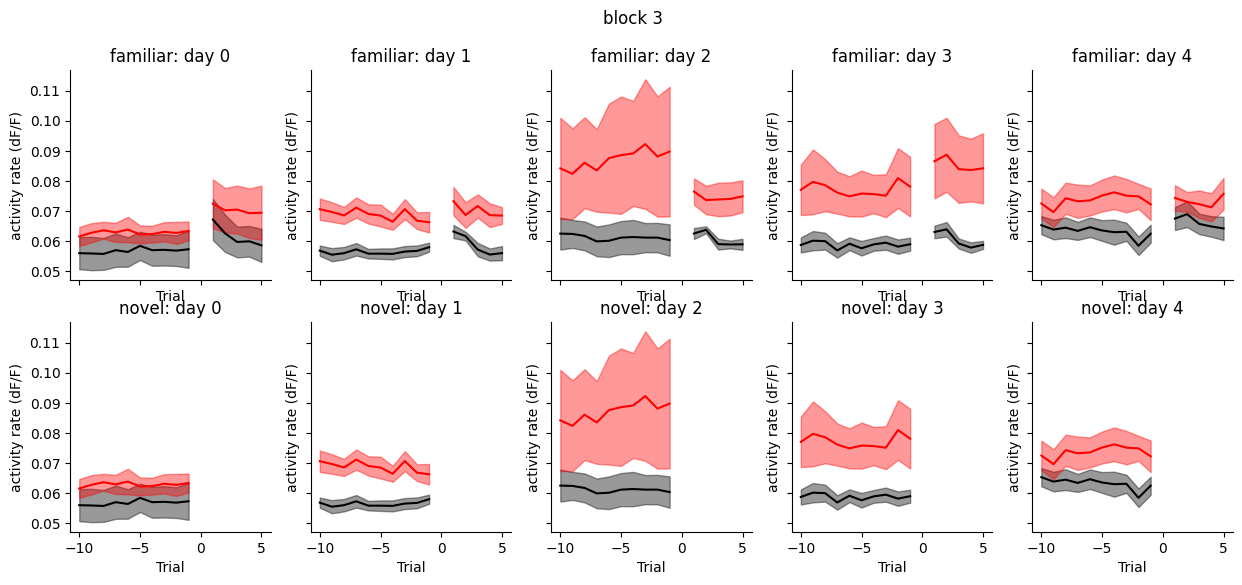

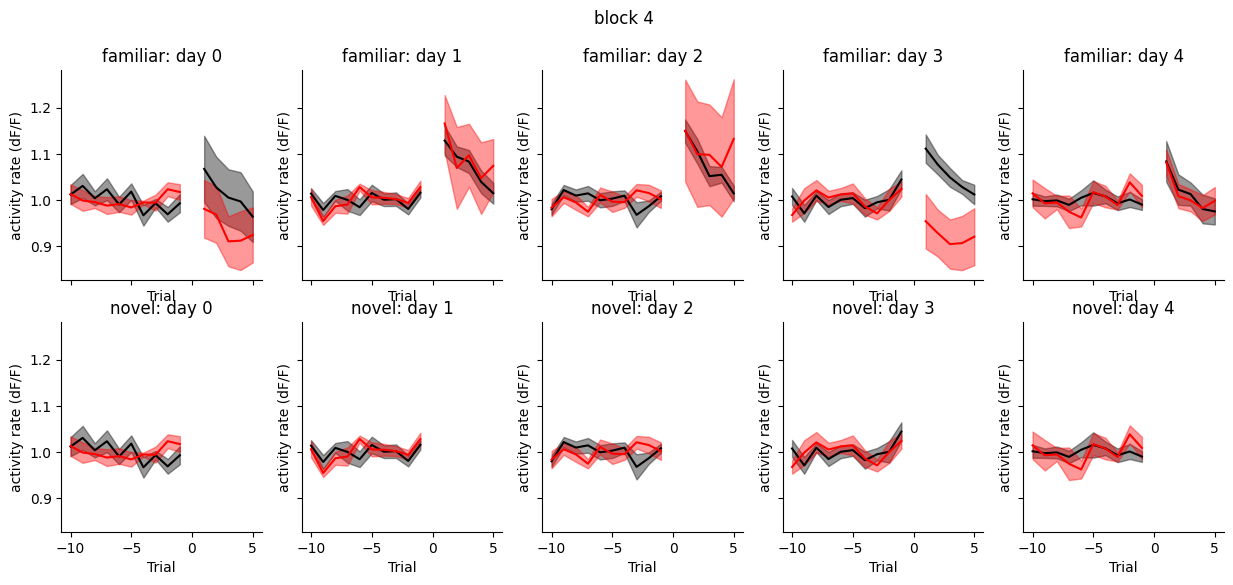

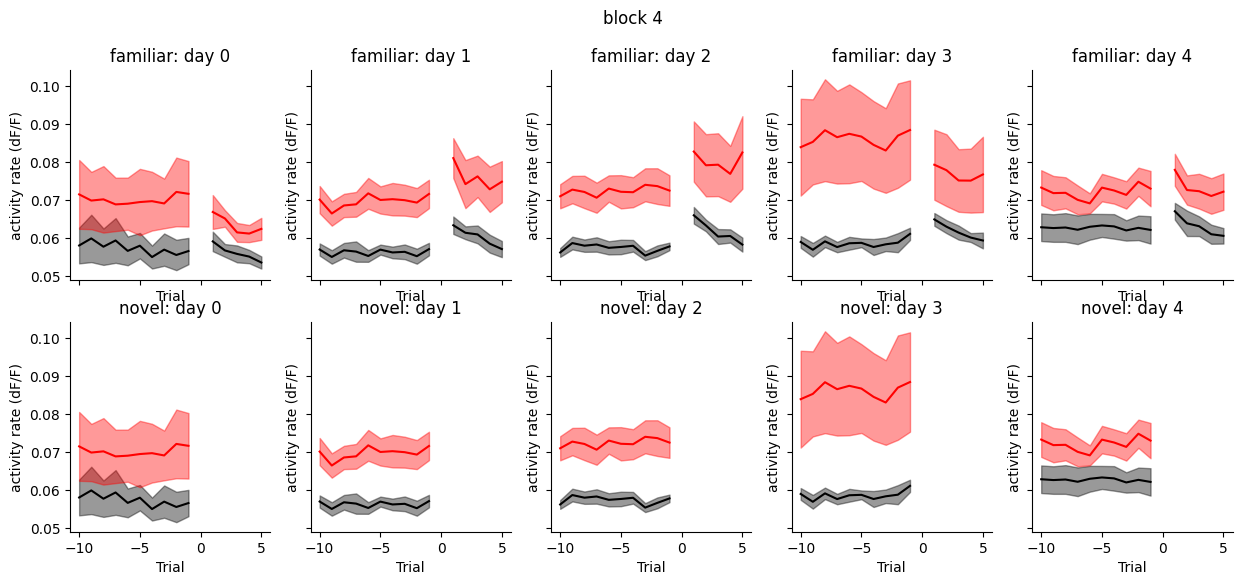

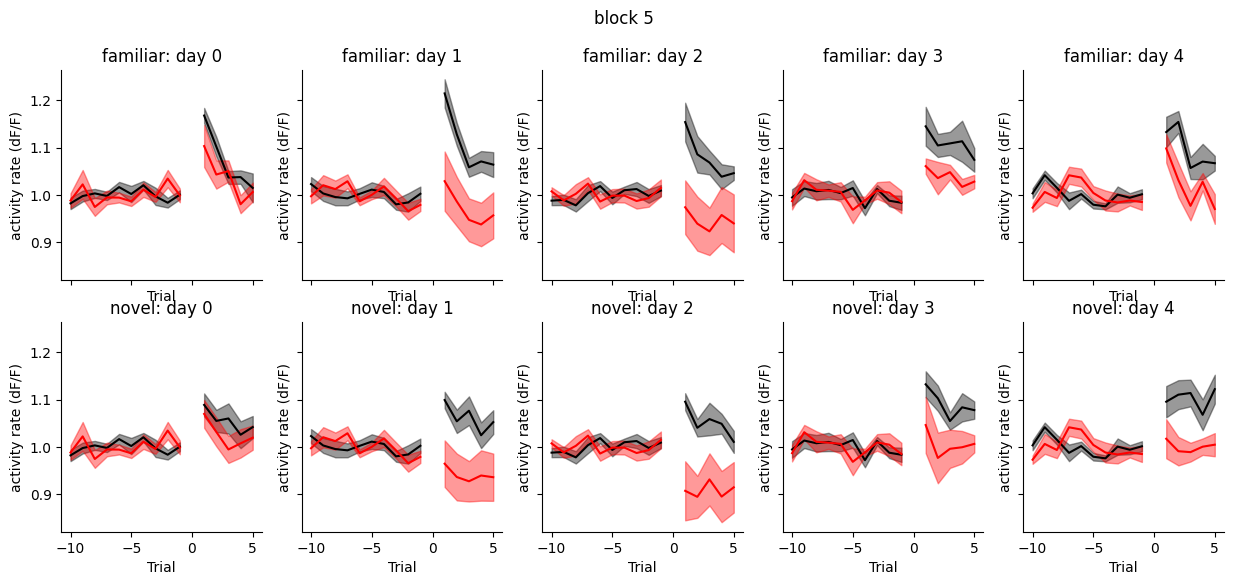

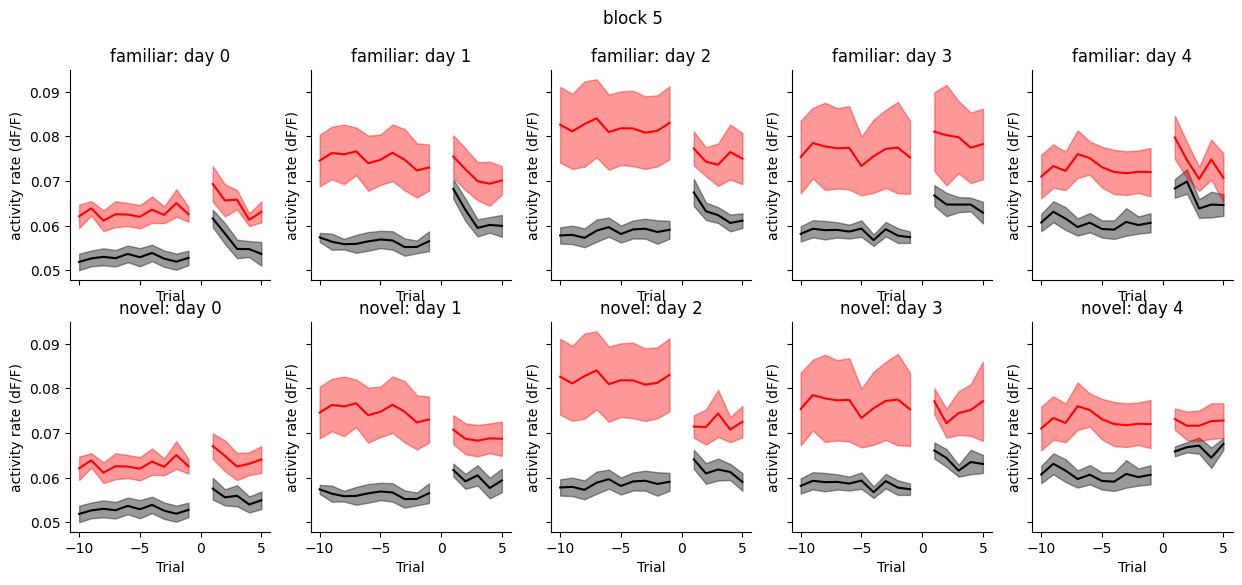

In [62]:
df_list = []
for block in (1,2,3,4,5):
    block_rate = stx.novel_activity_rate.BlockTransitionActivityRate(ts_key='F_dff', block=block)
    fig, ax = plot_block_avg(block_rate, key='act', norm = 'population', max_trial=5)
    fig.suptitle(f'block {block}')
    fig.savefig(figdir / f'block{block}_F_dff_norm.pdf')

    fig, ax = plot_block_avg(block_rate, key='act', norm = None, max_trial=5)
    fig.suptitle(f'block {block}')
    fig.savefig(figdir / f'block{block}_F_dff.pdf')
    block_rate.build_dataframe(norm='population')
    _df = block_rate.df
    _df['block'] = block
    df_list.append(_df)
df = pd.concat(df_list, ignore_index=True)

df.to_pickle('/home/mplitt/shuffle_pkls/dense_all_blocks_norm_activity.pkl')

In [31]:
import pickle
with open('/home/mplitt/shuffle_pkls/dense_all_blocks_norm_activity.pkl', 'rb') as file:
    df = pickle.load(file)

In [32]:
df = df.loc[(df['day']<5) * df['ttype'].isin(('familiar', 'novel'))]

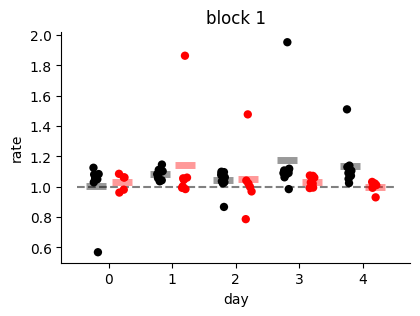

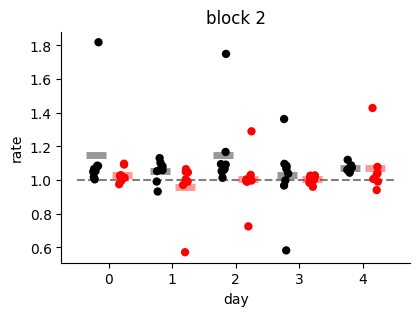

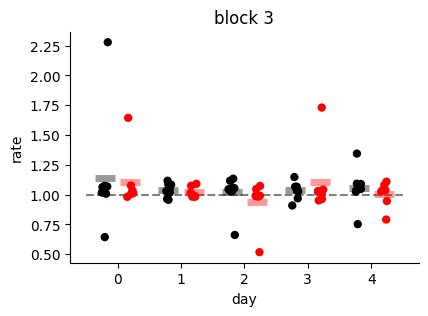

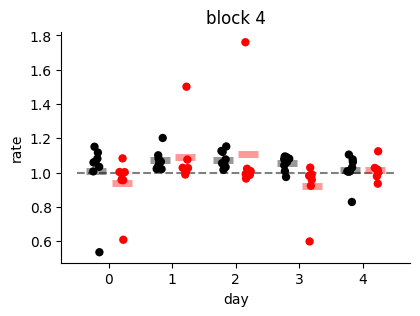

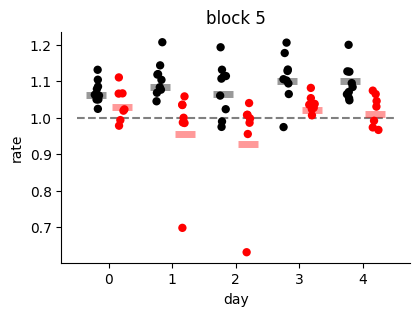

In [33]:
for block in range(1,6):
    tmp_df = df.loc[df['block']==block]
    fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)

    sns.stripplot(data=tmp_df.loc[tmp_df['ttype']=='familiar',:],
                x='day',
                y='rate',
                hue='condition', 
                hue_order=('ctrl', 'ko'), 
                palette=['black', 'red'],
                dodge=True,
                alpha=1.,s=6,
                ax=ax,
                legend=False)


    sns.pointplot(data=tmp_df.loc[tmp_df['ttype'].isin(('familiar','novel')),:],
                x='day',
                y='rate',
                errorbar=None,
                estimator=np.mean,
                hue='condition',
                dodge = .4,
                hue_order=('ctrl', 'ko'), 
                palette=['black', 'red'],
                ax=ax,
                linestyles="none",
                marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,zorder=10,
                )


    #
    ax.set_title('population normalized activity')
    ax.hlines(1,-.5,4.5, color='gray', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(f'block {block}')
    # ax.set_ylim([.7,1.3])

    fig.savefig(figdir / f'block{block}_activity_rate_by_day.pdf', bbox_inches='tight')


In [34]:
plot_mats = {}
for cond, mice in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    mat = np.zeros((5,5, len(mice)))*np.nan
    cond_mask = (df['condition']==cond) * (df['ttype']=='familiar')
    for i, block in enumerate(range(1,6)):
        block_mask = df['block'] == block
        for day in range(5):
            day_mask = df['day'] == day
            for k, mouse in enumerate(mice):

                mask = cond_mask*block_mask*day_mask*(df['mouse']==mouse)
                if mask.sum()>0:
                    mat[i, day, k] = df.loc[mask, 'rate'].values
            #     vals = df.loc[mask,'speed'].values
            # mat[i,day,:vals.shape[0]] = vals
    plot_mats[cond]=mat


/tmp/ipykernel_519232/57890512.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat[i, day, k] = df.loc[mask, 'rate'].values


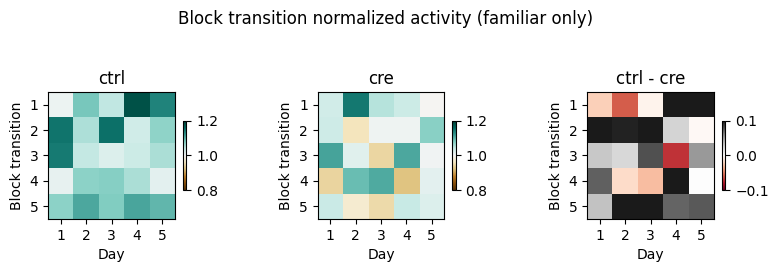

In [35]:
fig, ax =plt.subplots(1,3, figsize=[9,3])
fig.subplots_adjust(wspace=.7)
h = ax[0].imshow(np.nanmean(plot_mats['ctrl'],axis=-1), vmin=.8,vmax=1.2, cmap='BrBG')
ax[0].set_title('ctrl')

plt.colorbar(h, shrink=.3)
h = ax[1].imshow(np.nanmean(plot_mats['ko'], axis=-1), vmin=.8,vmax=1.2, cmap='BrBG')
ax[1].set_title('cre')
plt.colorbar(h, shrink=.3)

h = ax[2].imshow(np.nanmean(plot_mats['ctrl'], axis=-1)-np.nanmean(plot_mats['ko'], axis=-1), vmin=-.1, vmax=.1, cmap='RdGy')
plt.colorbar(h, shrink=.3)
ax[2].set_title('ctrl - cre')

for a in ax:
    a.set_xlabel('Day')
    a.set_ylabel('Block transition')
    a.set_xticks([0,1,2,3,4], labels = [1,2,3,4,5])
    a.set_yticks([0,1,2,3,4], labels = [1,2,3,4,5])
fig.suptitle('Block transition normalized activity (familiar only)')
fig.savefig(figdir / "fam_norm_activity_allblocks.pdf")

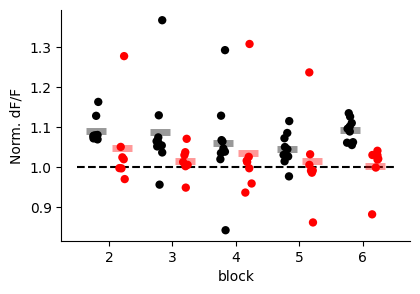

In [36]:
rows = []
for cond, mat in plot_mats.items():
    n_mice = mat.shape[-1]
    for m in range(n_mice):
        for block in range(5):
            rows.append({'condition': cond,
                        'mouse': m,
                        'mu': np.nanmean(mat[block,:,m].ravel()),
                        'block': block,
                        'plot_x': 0,})
tmp_df = pd.DataFrame(rows)


fig, ax = plt.subplots(figsize=[4.5,3])
sns.stripplot(data=tmp_df,
            x='block',
            y='mu',
            hue='condition', 
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            dodge=True,
            alpha=1.,s=6,
            ax=ax,
            legend=False)

sns.pointplot(data=tmp_df,
            x='block',
            y='mu',
            errorbar=None,
            estimator=np.mean,
            hue='condition',
            dodge = .4,
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,zorder=10,
            )


ax.plot([-.5,4.5], [1,1], linestyle='--', color='k', zorder=-1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(np.arange(5), labels=np.arange(2,7))
# ax.set_xlabel('')
ax.set_ylabel('Norm. dF/F')

fig.savefig(figdir / "fam_norm_activity_summary.pdf")


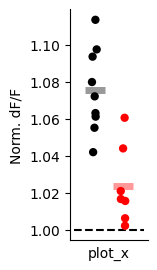

In [41]:
rows = []
for cond, mat in plot_mats.items():
    n_mice = mat.shape[-1]
    for m in range(n_mice):
        # for block in range(5):
            rows.append({'condition': cond,
                        'mouse': m,
                        'mu': np.nanmean(mat[:,:,m].ravel()),
                        # 'block': block,
                        'plot_x': 0,})
tmp_df = pd.DataFrame(rows)


fig, ax = plt.subplots(figsize=[1,3])
sns.stripplot(data=tmp_df,
            x='plot_x',
            y='mu',
            hue='condition', 
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            dodge=True,
            alpha=1.,s=6,
            ax=ax,
            legend=False)

sns.pointplot(data=tmp_df,
            x='plot_x',
            y='mu',
            errorbar=None,
            estimator=np.mean,
            hue='condition',
            dodge = .4,
            hue_order=('ctrl', 'ko'), 
            palette=['black', 'red'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,zorder=10,
            )


ax.plot([-.5,.5], [1,1], linestyle='--', color='k', zorder=-1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks([])
# ax.set_xlabel('')
ax.set_ylabel('Norm. dF/F')

fig.savefig(figdir / "fam_norm_activity_summary_across_blocks.pdf")


In [39]:
pg.pairwise_tests(data=tmp_df, dv='mu', between='condition', subject='mouse', parametric=False, padjust='holm')

,Contrast,A,B,Paired,Parametric,U-val,alternative,p-unc,hedges
0,condition,ctrl,ko,False,False,60.0,two-sided,0.001224,2.206141


# Sparse

In [42]:
def plot_block_avg_sparse(block_rate_sparse, key='act', norm = 'population', max_trial=5):
    fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


    for day in np.arange(5):
        base = {'channel_0': np.zeros([len(sparse_mice),10])*np.nan, 'channel_1': np.zeros([len(sparse_mice),10])*np.nan}
        fam = {'channel_0': np.zeros([len(sparse_mice),max_trial])*np.nan, 'channel_1': np.zeros([len(sparse_mice),max_trial])*np.nan}
        nov = {'channel_0': np.zeros([len(sparse_mice),max_trial])*np.nan, 'channel_1': np.zeros([len(sparse_mice),max_trial])*np.nan}

        for i, mouse in enumerate(sparse_mice):
            for chan in ('channel_0', 'channel_1'):
                if mouse == 'SparseKO_09' and day ==2:
                        continue
                
                data = block_rate_sparse.activity_rates[mouse][day][chan]

                if norm is None:

                    if key == 'act':
                       
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[chan][i,:_base.shape[0]] = _base
                    fam[chan][i,:_fam.shape[0]] = _fam
                    nov[chan][i,:_nov.shape[0]] = _nov

                elif norm == 'population':
                    if key == 'act':
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[chan][i,:_base.shape[0]] = _base/_base.mean()
                    fam[chan][i,:_fam.shape[0]] = _fam/_base.mean()
                    nov[chan][i,:_nov.shape[0]] = _nov/_base.mean()
                elif norm == 'cell':
                    cell_denom = data['baseline_avg_act']

                    _base = np.nanmean(np.nanmean(data[f'baseline_{key}']/cell_denom,axis=1),axis=-1)
                    base[chan][i,:_base.shape[0]] = _base

                    _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}']/cell_denom,axis=1),axis=-1)[:max_trial]
                    fam[chan][i,:_fam.shape[0]] = _fam

                    _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}']/cell_denom,axis=1), axis=-1)[:max_trial]
                    nov[chan][i,:_nov.shape[0]] = _nov

               

        for chan, color in zip(('channel_1','channel_0'), ('black', 'red')):
            x_base = np.arange(-10,0)
            mu, sem = np.nanmean(base[chan], axis=0), sp.stats.sem(base[chan],axis=0, nan_policy='omit')
            ax[0,day].plot(x_base, mu, color=color)
            ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            ax[1,day].plot(x_base, mu, color=color)
            ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            x_block = np.arange(1,max_trial+1)
            mu, sem = np.nanmean(fam[chan], axis=0), sp.stats.sem(fam[chan],axis=0, nan_policy='omit')
            ax[0,day].plot(x_block, mu, color=color)
            ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            mu, sem = np.nanmean(nov[chan], axis=0), sp.stats.sem(nov[chan],axis=0, nan_policy='omit')
            ax[1,day].plot(x_block, mu, color=color)
            ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            ax[0,day].set_title(f'familiar: day {day}')
            ax[1,day].set_title(f'novel: day {day}')

    for a in ax.flatten():
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)
        if key == 'act':
            a.set_ylabel('activity rate (dF/F)')
        else:
            a.set_ylabel(key)
        
        a.set_xlabel('Trial')
    return fig, ax

SparseKO_02
SparseKO_06
SparseKO_08


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:311: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],


SparseKO_10


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:311: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:311: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:311: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],


SparseKO_11


...

SparseKO_10


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:311: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:311: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:311: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],


SparseKO_11
SparseKO_13


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:311: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:311: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:311: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:311: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.nanmean(np.nanmean(sess.trial_matrices[_ts_key][baseline_trials,:,:],
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:311: RuntimeWarning: Mean of empty slice
  d['baseline_avg_act'] = np.

SparseKO_09


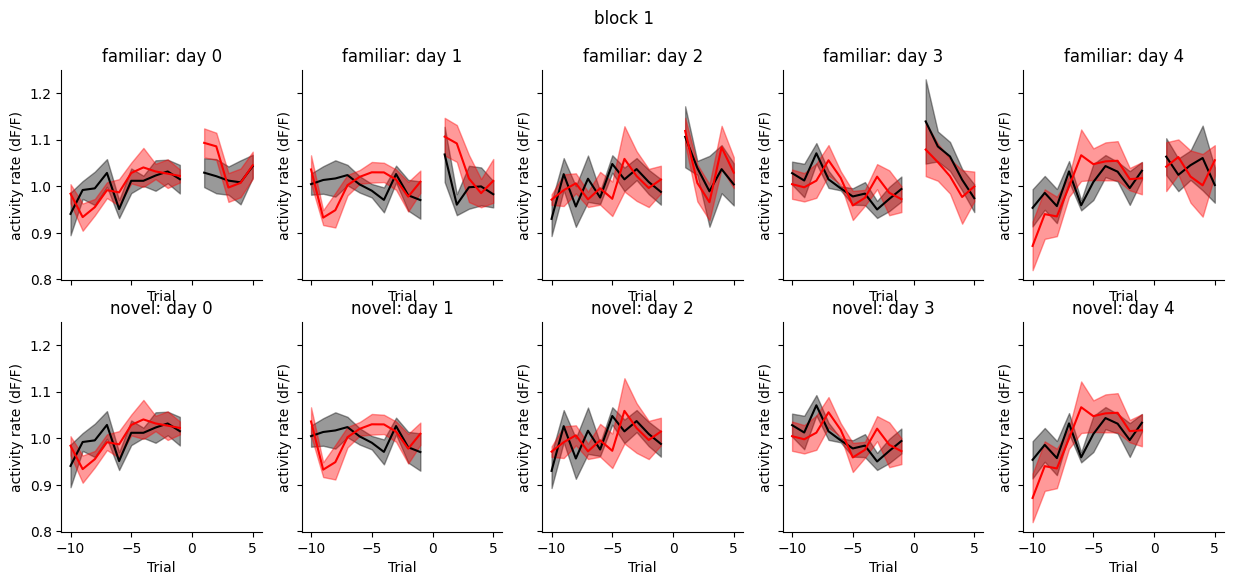

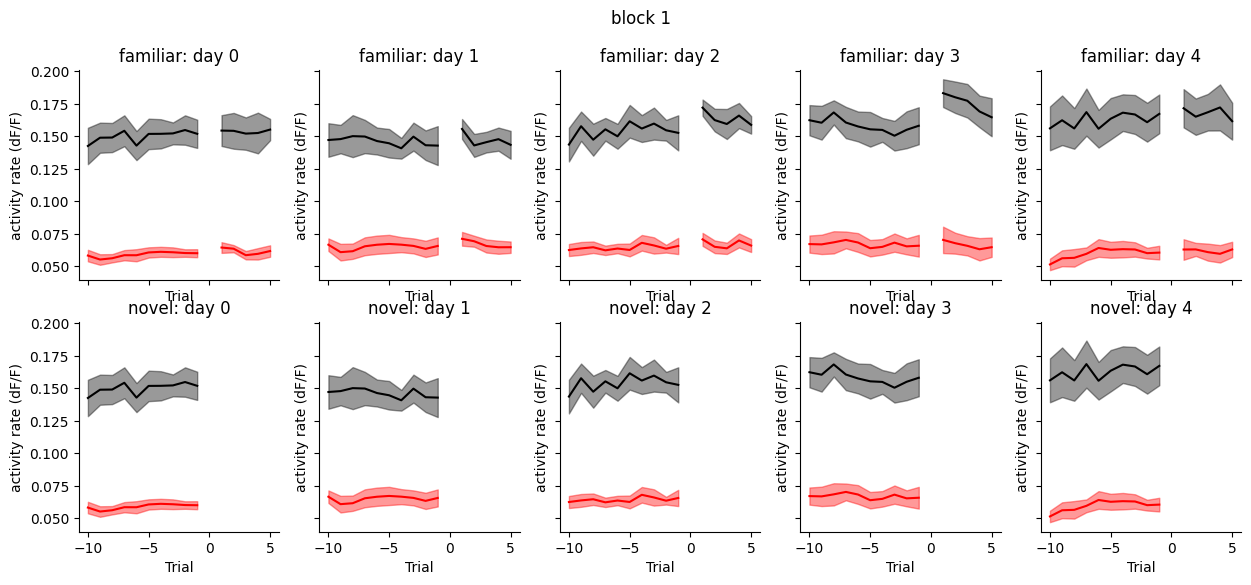

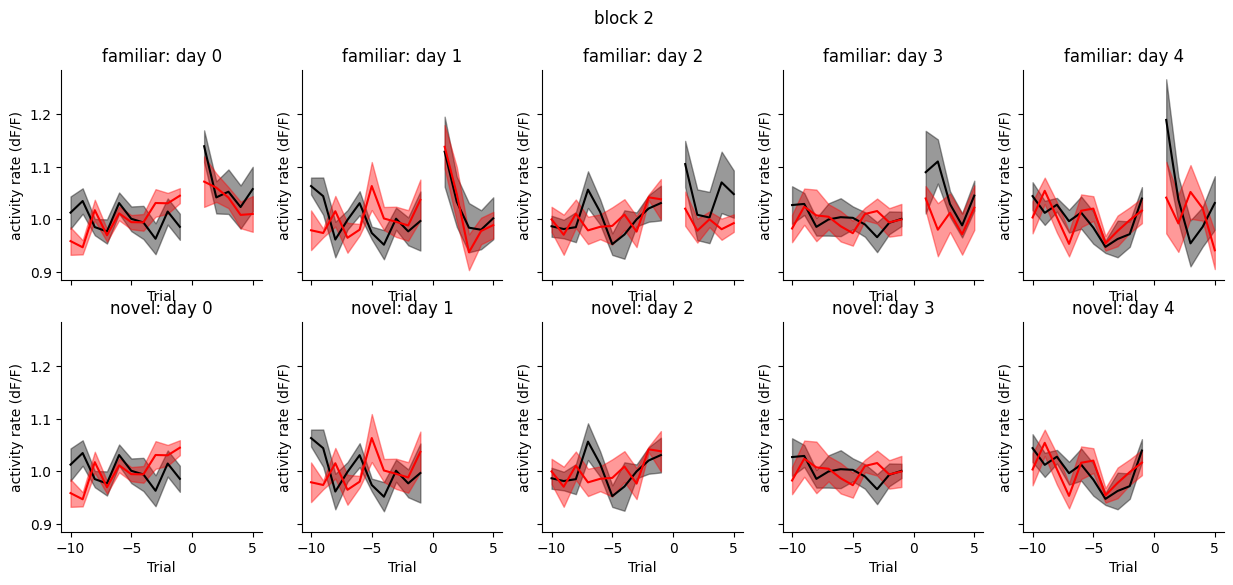

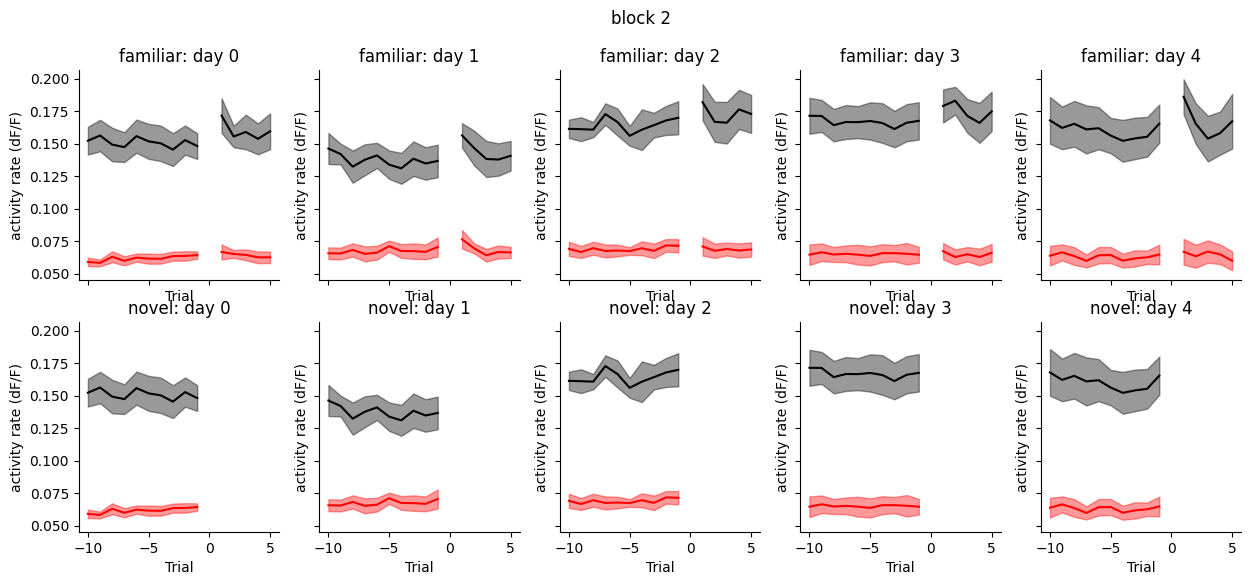

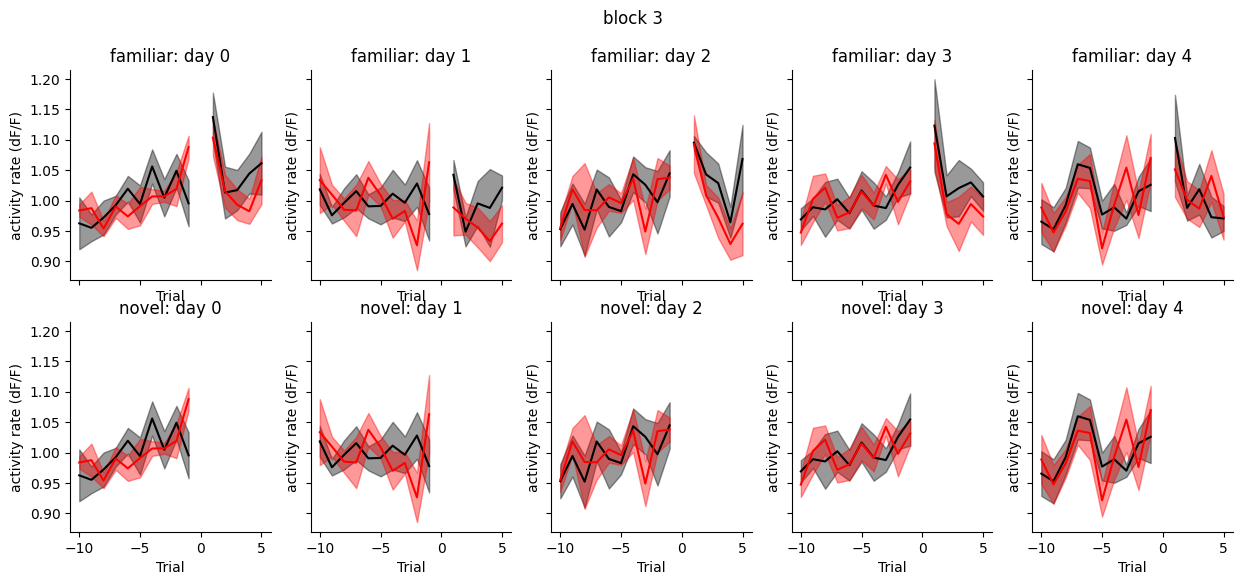

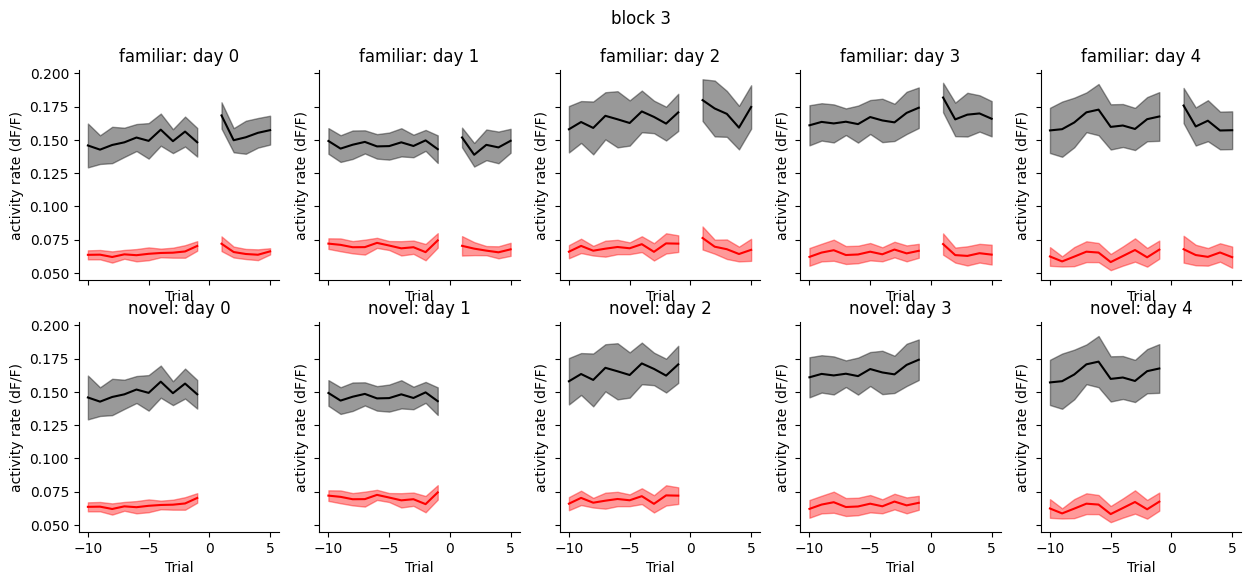

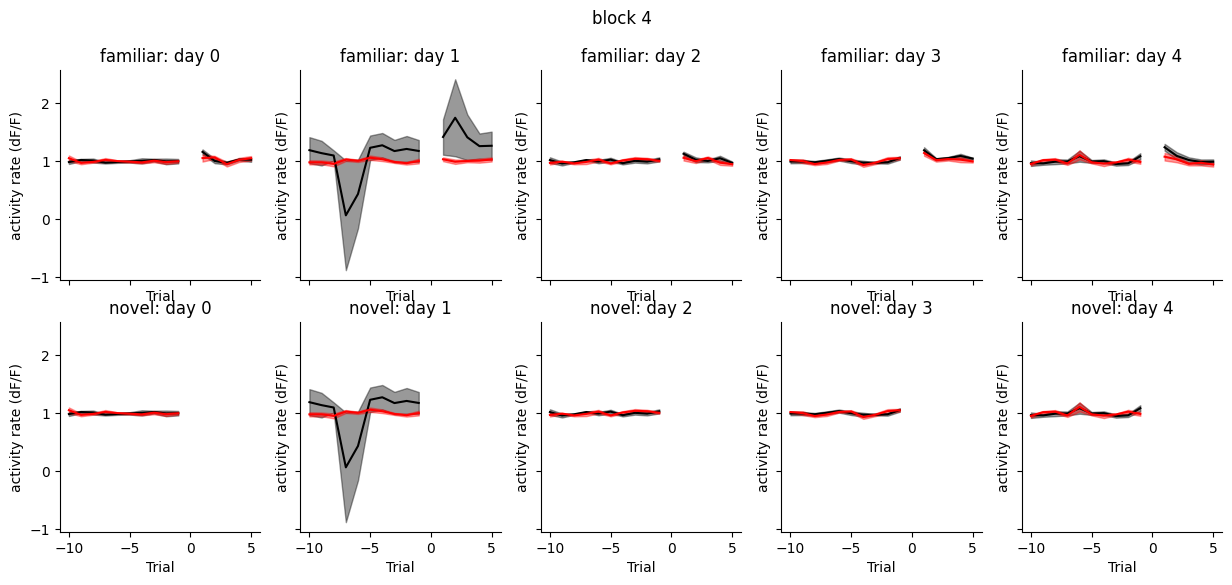

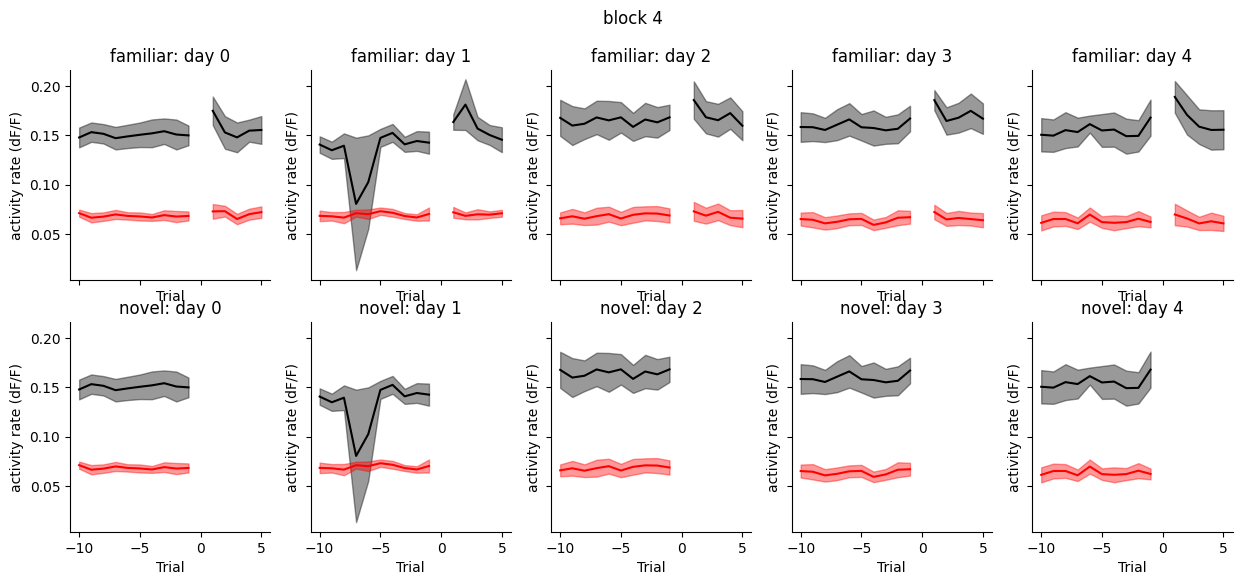

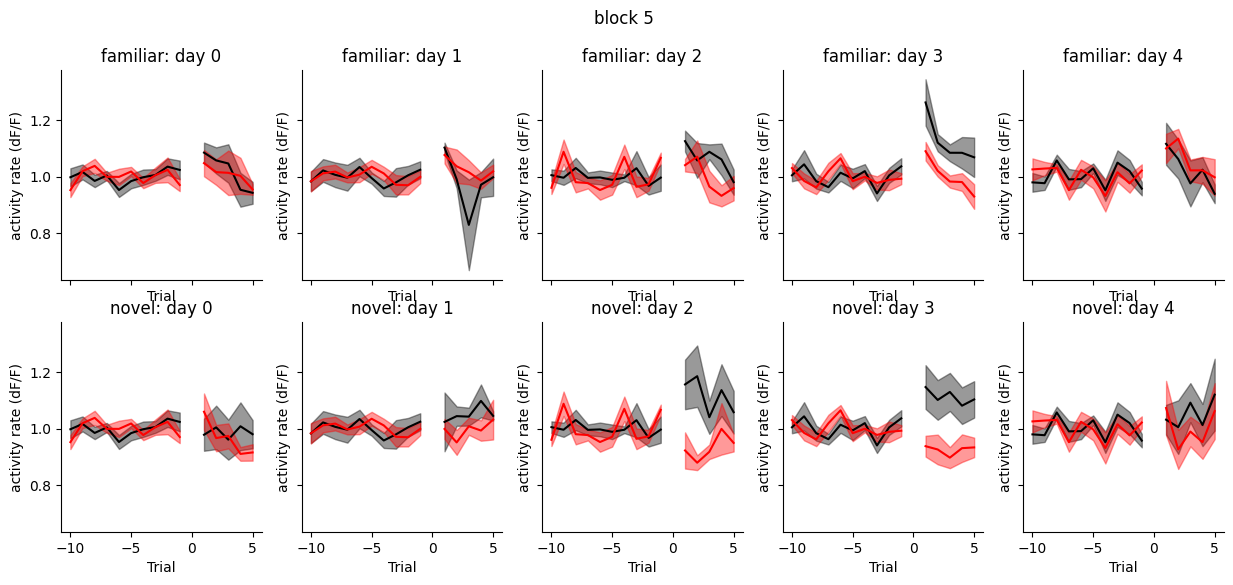

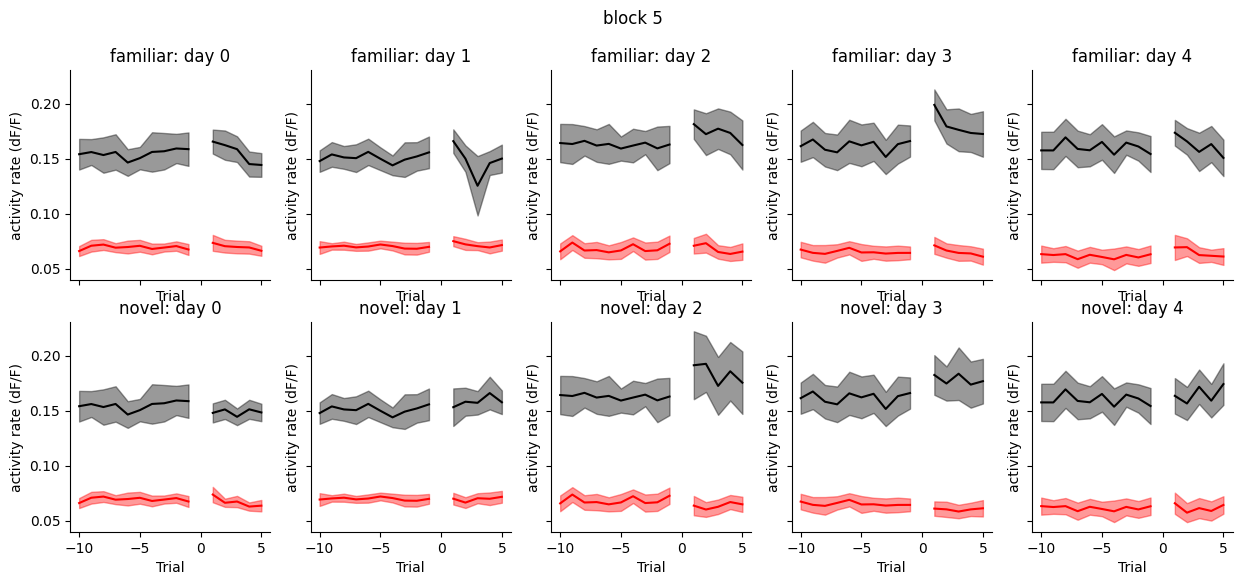

In [83]:
df_list = []
for block in (1,2,3,4,5):
    block_rate = stx.novel_activity_rate.BlockTransitionActivityRate_Sparse(ts_key='F_dff', block=block)
    fig, ax = plot_block_avg_sparse(block_rate, key='act', norm = 'population', max_trial=5)
    fig.suptitle(f'block {block}')
    fig.savefig(figdir / f'sparse_block{block}_F_dff_norm.pdf')

    fig, ax = plot_block_avg_sparse(block_rate, key='act', norm = None, max_trial=5)
    fig.suptitle(f'block {block}')
    fig.savefig(figdir / f'sparse_block{block}_F_dff.pdf')
    block_rate.build_dataframe(norm='population')
    _df = block_rate.df
    _df['block'] = block
    df_list.append(_df)
df = pd.concat(df_list, ignore_index=True)

df.to_pickle('/home/mplitt/shuffle_pkls/sparse_all_blocks_norm_activity.pkl')

In [43]:
with open('/home/mplitt/shuffle_pkls/sparse_all_blocks_norm_activity.pkl', 'rb') as file:
    df = pickle.load(file)

In [44]:
df = df.loc[(df['day']<5) * df['ttype'].isin(('familiar', 'novel'))]

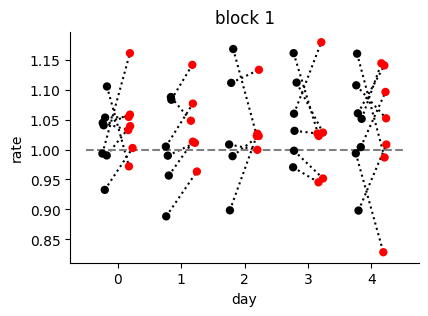

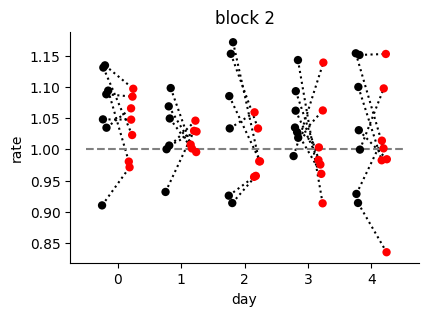

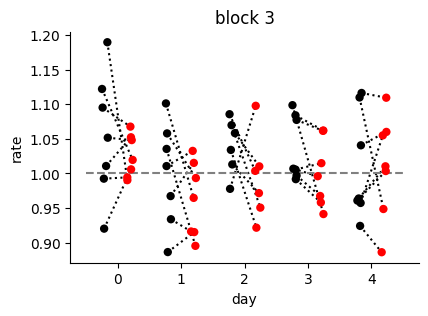

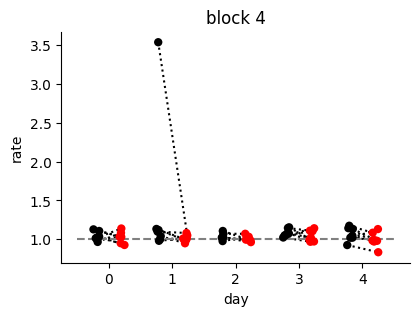

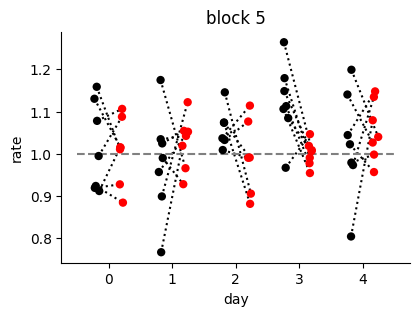

In [45]:
for block in range(1,6):
    tmp_df = df.loc[df['block']==block]
    fig,ax = plt.subplots( figsize=[4.5,3], sharey = True)

    sns.stripplot(data=tmp_df.loc[tmp_df['ttype']=='familiar',:],
                x='day',
                y='rate',
                hue='channel', 
                hue_order=('channel_1', 'channel_0'), 
                palette=['black', 'red'],
                dodge=True,
                alpha=1.,s=6,
                ax=ax,
                legend=False)


    for d in range(0,10,2):
        for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
            ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)


    #
    ax.set_title('population normalized activity')
    ax.hlines(1,-.5,4.5, color='gray', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(f'block {block}')

    fig.savefig(figdir / f'sparse_block{block}_activity_rate_by_day.pdf', bbox_inches='tight')


In [46]:
plot_mats = {}
for chan in ('channel_1', 'channel_0'):

    mat = np.zeros((5,5, len(mice)))*np.nan
    cond_mask = (df['channel']==chan) * (df['ttype']=='familiar')
    for i, block in enumerate(range(1,6)):
        block_mask = df['block'] == block
        for day in range(5):
            day_mask = df['day'] == day
            for k, mouse in enumerate(sparse_mice):
                mask = cond_mask*block_mask*day_mask*(df['mouse']==mouse)
                
                # print(mask.sum())
                if mask.sum()>0:
                    mat[i, day, k] = df.loc[mask, 'rate'].values
            #     vals = df.loc[mask,'speed'].values
            # mat[i,day,:vals.shape[0]] = vals
    plot_mats[chan]=mat


/tmp/ipykernel_519232/790969941.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat[i, day, k] = df.loc[mask, 'rate'].values


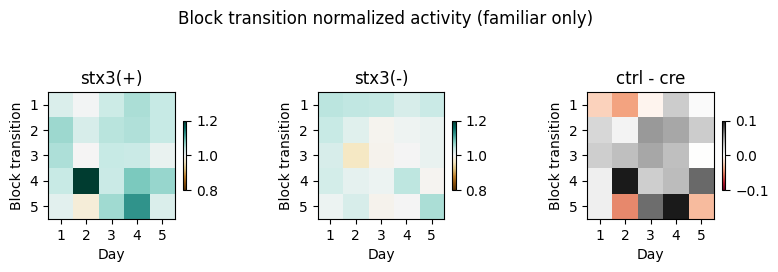

In [47]:
fig, ax =plt.subplots(1,3, figsize=[9,3])
fig.subplots_adjust(wspace=.7)
h = ax[0].imshow(np.nanmean(plot_mats['channel_1'],axis=-1), vmin=.8,vmax=1.2, cmap='BrBG')
ax[0].set_title('stx3(+)')

plt.colorbar(h, shrink=.3)
h = ax[1].imshow(np.nanmean(plot_mats['channel_0'], axis=-1), vmin=.8,vmax=1.2, cmap='BrBG')
ax[1].set_title('stx3(-)')
plt.colorbar(h, shrink=.3)

h = ax[2].imshow(np.nanmean(plot_mats['channel_1']-plot_mats['channel_0'], axis=-1), vmin=-.1, vmax=.1, cmap='RdGy')
plt.colorbar(h, shrink=.3)
ax[2].set_title('ctrl - cre')

for a in ax:
    a.set_xlabel('Day')
    a.set_ylabel('Block transition')
    a.set_xticks([0,1,2,3,4], labels = [1,2,3,4,5])
    a.set_yticks([0,1,2,3,4], labels = [1,2,3,4,5])
fig.suptitle('Block transition normalized activity (familiar only)')
fig.savefig(figdir / "sparse_fam_norm_activity_allblocks.pdf")

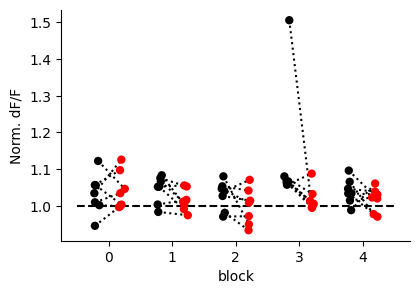

In [48]:
rows = []
for chan, mat in plot_mats.items():
    n_mice = mat.shape[-1]
    for m in range(n_mice):
        for block in range(5):
            rows.append({'channel': chan,
                        'mouse': m,
                        'mu': np.nanmean(mat[block,:,m].ravel()),
                        'block': block,
                        'plot_x': 0,})
tmp_df = pd.DataFrame(rows)


fig, ax = plt.subplots(figsize=[4.5,3])
sns.stripplot(data=tmp_df,
            x='block',
            y='mu',
            hue='channel', 
            hue_order=('channel_1', 'channel_0'), 
            palette=['black', 'red'],
            dodge=True,
            alpha=1.,s=6,
            ax=ax,
            legend=False)
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)



ax.plot([-.5,4.5], [1,1], linestyle='--', color='k', zorder=-1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.set_xticks([])
# ax.set_xlabel('')
ax.set_ylabel('Norm. dF/F')

fig.savefig(figdir / "sparse_fam_norm_activity_summary.pdf")


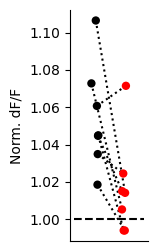

In [57]:
rows = []
for chan, mat in plot_mats.items():
    n_mice = mat.shape[-1]
    for m in range(n_mice):
        # for block in range(5):
            rows.append({'channel': chan,
                        'mouse': m,
                        'mu': np.nanmean(mat[:,:,m].ravel()),
                        # 'block': block,
                        'plot_x': 0,})
tmp_df = pd.DataFrame(rows)


fig, ax = plt.subplots(figsize=[1,3])
sns.stripplot(data=tmp_df,
            x='plot_x',
            y='mu',
            hue='channel', 
            hue_order=('channel_1', 'channel_0'), 
            palette=['black', 'red'],
            dodge=True,
            alpha=1.,s=6,
            ax=ax,
            legend=False)
for d in range(0,2,2):
    for (x0, y0), (x1, y1) in zip(ax.collections[d].get_offsets(), ax.collections[d+1].get_offsets()):
        ax.plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)



ax.plot([-.5,.5], [1,1], linestyle='--', color='k', zorder=-1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('Norm. dF/F')

fig.savefig(figdir / "sparse_fam_norm_activity_summary_across_blocks.pdf")


In [58]:
pg.pairwise_tests(data=tmp_df, dv='mu', within='channel', subject='mouse', parametric=False, padjust='holm')

,Contrast,A,B,Paired,Parametric,W-val,alternative,p-unc,hedges
0,channel,channel_0,channel_1,True,False,2.0,two-sided,0.046875,-1.28023


In [3]:
def plot_block_avg_behavior(block_rate, key='act', norm = 'population', max_trial=5):
    fig, ax = plt.subplots(2,5, figsize=[15,6], sharex=True, sharey=True)


    for day in np.arange(5):
        base = {'ctrl': np.zeros([len(ctrl_mice),10])*np.nan, 'ko': np.zeros([len(ko_mice),10])*np.nan, 'sparse': np.zeros([len(sparse_mice), 10])*np.nan}
        fam = {'ctrl': np.zeros([len(ctrl_mice),max_trial])*np.nan, 'ko': np.zeros([len(ko_mice),max_trial])*np.nan, 'sparse': np.zeros([len(sparse_mice), max_trial])*np.nan}
        nov = {'ctrl': np.zeros([len(ctrl_mice),max_trial])*np.nan, 'ko': np.zeros([len(ko_mice),max_trial])*np.nan, 'sparse': np.zeros([len(sparse_mice), max_trial])*np.nan}

        for cond, mice in zip(('ctrl','ko', 'sparse'), (ctrl_mice, ko_mice, sparse_mice)):
            for i, mouse in enumerate(mice):
                try:
                    data = block_rate.activity_rates[cond][mouse][day]
                except:
                    continue

                if norm is None:

                    if key == 'act':
                       
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[cond][i,:_base.shape[0]] = _base
                    fam[cond][i,:_fam.shape[0]] = _fam
                    nov[cond][i,:_nov.shape[0]] = _nov

                elif norm == 'population':
                    if key == 'act':
                        _base = np.nanmean(np.nanmean(data[f'baseline_{key}'],axis=1),axis=-1)
                        _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}'],axis=1),axis=-1)[:max_trial]
                        _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}'],axis=1), axis=-1)[:max_trial]
                    else:
                        _base = np.nanmean(data[f'baseline_{key}'],axis=1)
                        _fam = np.nanmean(data[f'block_fam_{key}'],axis=1)[:max_trial]
                        _nov = np.nanmean(data[f'block_nov_{key}'],axis=1)[:max_trial]
                        
                    base[cond][i,:_base.shape[0]] = _base/_base.mean()
                    fam[cond][i,:_fam.shape[0]] = _fam/_base.mean()
                    nov[cond][i,:_nov.shape[0]] = _nov/_base.mean()
                elif norm == 'cell':
                    cell_denom = data['baseline_avg_act']

                    _base = np.nanmean(np.nanmean(data[f'baseline_{key}']/cell_denom,axis=1),axis=-1)
                    base[cond][i,:_base.shape[0]] = _base

                    _fam = np.nanmean(np.nanmean(data[f'block_fam_{key}']/cell_denom,axis=1),axis=-1)[:max_trial]
                    fam[cond][i,:_fam.shape[0]] = _fam

                    _nov = np.nanmean(np.nanmean(data[f'block_nov_{key}']/cell_denom,axis=1), axis=-1)[:max_trial]
                    nov[cond][i,:_nov.shape[0]] = _nov

        for cond, color in zip(('ctrl','ko', 'sparse'), ('black', 'red', 'purple')):
            x_base = np.arange(-10,0)
            mu, sem = np.nanmean(base[cond], axis=0), sp.stats.sem(base[cond],axis=0, nan_policy='omit')
            ax[0,day].plot(x_base, mu, color=color)
            ax[0,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            ax[1,day].plot(x_base, mu, color=color)
            ax[1,day].fill_between(x_base, mu-sem , mu+sem, alpha=.4, color=color)

            x_block = np.arange(1,max_trial+1)
            mu, sem = np.nanmean(fam[cond], axis=0), sp.stats.sem(fam[cond],axis=0, nan_policy='omit')
            ax[0,day].plot(x_block, mu, color=color)
            ax[0,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
            ax[1,day].plot(x_block, mu, color=color)
            ax[1,day].fill_between(x_block, mu-sem , mu+sem, alpha=.4, color=color)

            ax[0,day].set_title(f'familiar: day {day}')
            ax[1,day].set_title(f'novel: day {day}')

    for a in ax.flatten():
        a.spines['top'].set_visible(False)
        a.spines['right'].set_visible(False)
        if key == 'act':
            a.set_ylabel('activity rate (dF/F)')
        else:
            a.set_ylabel(key)
        a.set_xlabel('Trial')
    return fig, ax

4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:656: RuntimeWarning: Mean of empty slice.
  'novel': nov_speed.mean()}
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:659: RuntimeWarning: Mean of empty slice.
  'novel': nov_licks.mean()}
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:631: RuntimeWarning: Mean of empty slice.
  fam_speed = fam_speed/base_speed.mean()
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:632: RuntimeWarning: Mean of empty slice.
  nov_speed = nov_speed/base_speed.mean()
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:634: RuntimeWarning: Mean of empty slice.
  fam_licks = fam_licks/base_licks.mean()
/home/mplitt/repos/STX3KO_analyses/STX3KO_analys

4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:656: RuntimeWarning: Mean of empty slice.
  'novel': nov_speed.mean()}
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:659: RuntimeWarning: Mean of empty slice.
  'novel': nov_licks.mean()}
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:631: RuntimeWarning: Mean of empty slice.
  fam_speed = fam_speed/base_speed.mean()
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:632: RuntimeWarning: Mean of empty slice.
  nov_speed = nov_speed/base_speed.mean()
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:634: RuntimeWarning: Mean of empty slice.
  fam_licks = fam_licks/base_licks.mean()
/home/mplitt/repos/STX3KO_analyses/STX3KO_analys

4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:656: RuntimeWarning: Mean of empty slice.
  'novel': nov_speed.mean()}
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:659: RuntimeWarning: Mean of empty slice.
  'novel': nov_licks.mean()}
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:626: RuntimeWarning: Mean of empty slice
  base_licks = np.nanmean(data['baseline_licks'],axis=1)
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:627: RuntimeWarning: Mean of empty slice
  fam_licks = np.nanmean(data['block_fam_licks'],axis=1)[:max_trial]
/tmp/ipykernel_528329/1380806315.py:72: RuntimeWarning: Mean of empty slice
  mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit

4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09


/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:656: RuntimeWarning: Mean of empty slice.
  'novel': nov_speed.mean()}
/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:659: RuntimeWarning: Mean of empty slice.
  'novel': nov_licks.mean()}
/home/mplitt/repos/STX3KO_analyses/STX3KO_analyses/novel_activity_rate.py:626: RuntimeWarning: Mean of empty slice
  base_licks = np.nanmean(data['baseline_licks'],axis=1)
/tmp/ipykernel_528329/1380806315.py:72: RuntimeWarning: Mean of empty slice
  mu, sem = np.nanmean(nov[cond], axis=0), sp.stats.sem(nov[cond],axis=0, nan_policy='omit')
/tmp/ipykernel_528329/1380806315.py:72: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of retu

4467331.1
4467331.2
4467332.1
4467332.2
4467333.1
mCherry6
mCherry7
mCherry8
mCherry9
4467975.1
4467975.2
4467975.3
4467975.4
4467975.5
Cre7
Cre9
SparseKO_02
SparseKO_06
SparseKO_08
SparseKO_10
SparseKO_11
SparseKO_13
SparseKO_09


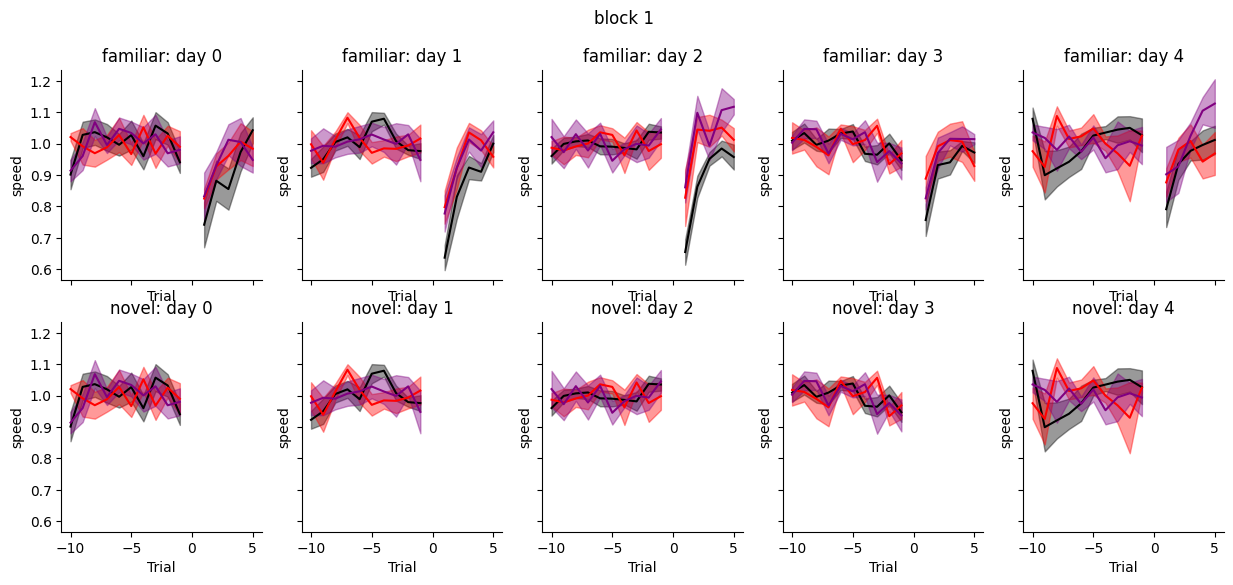

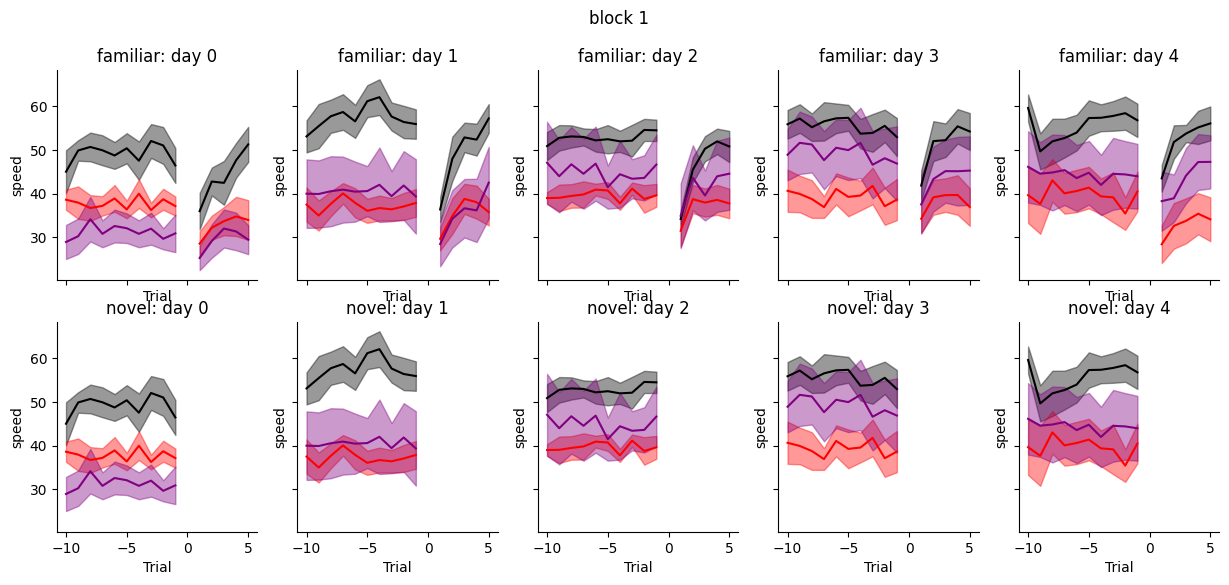

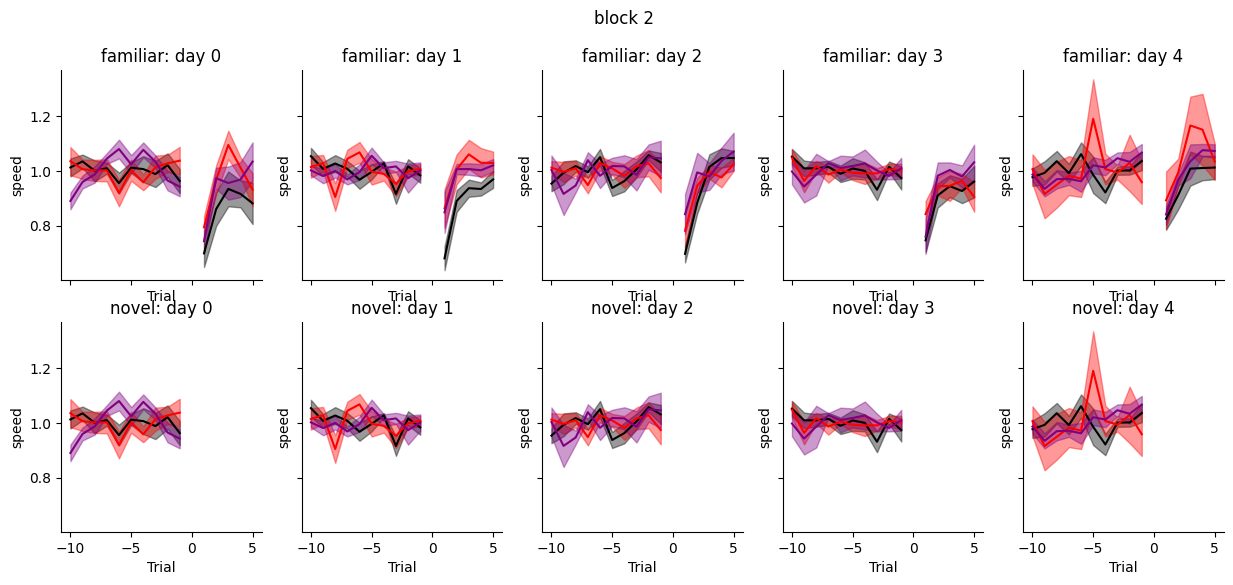

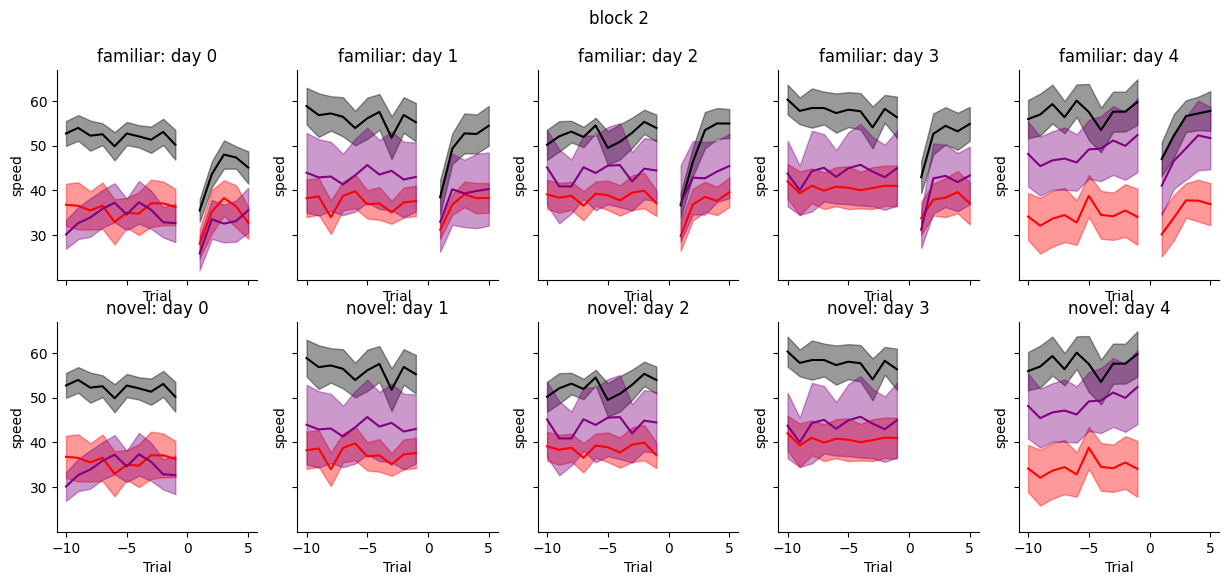

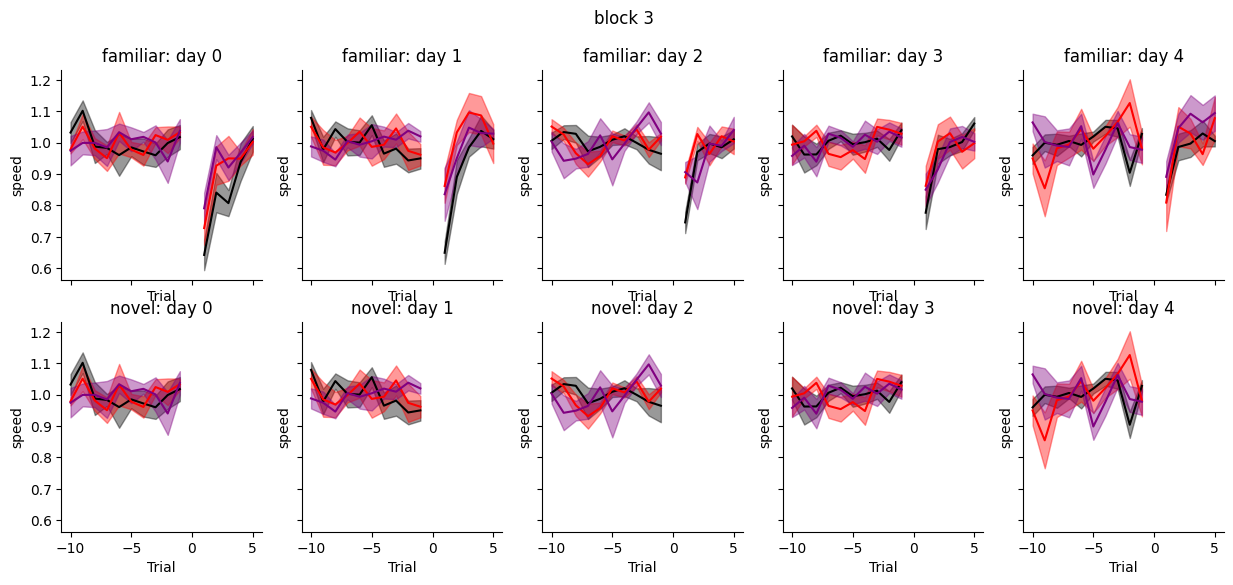

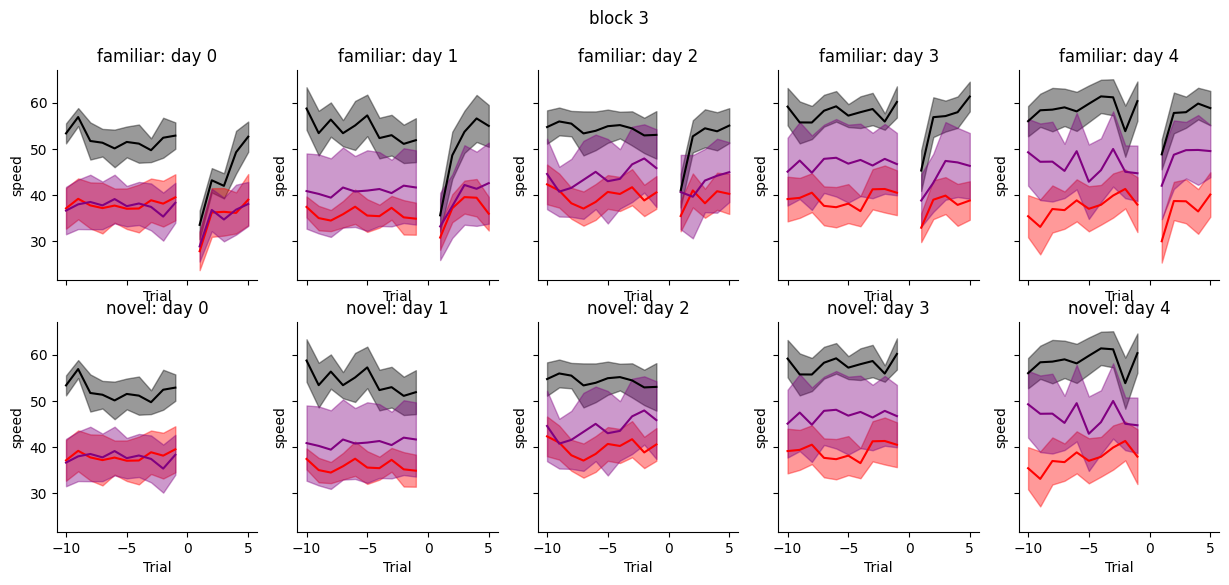

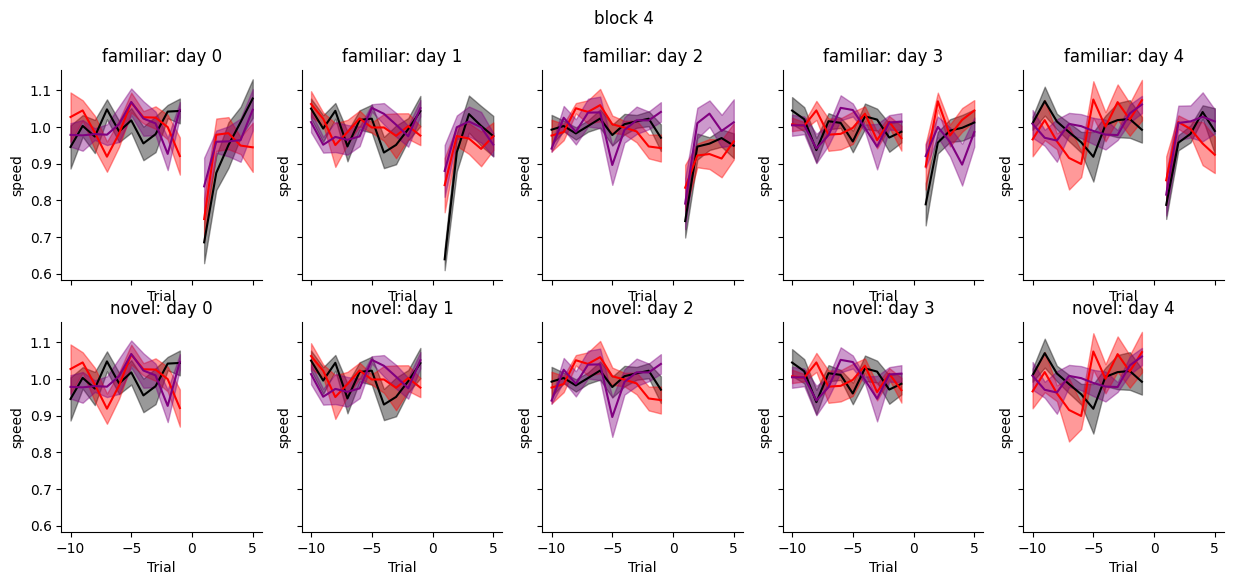

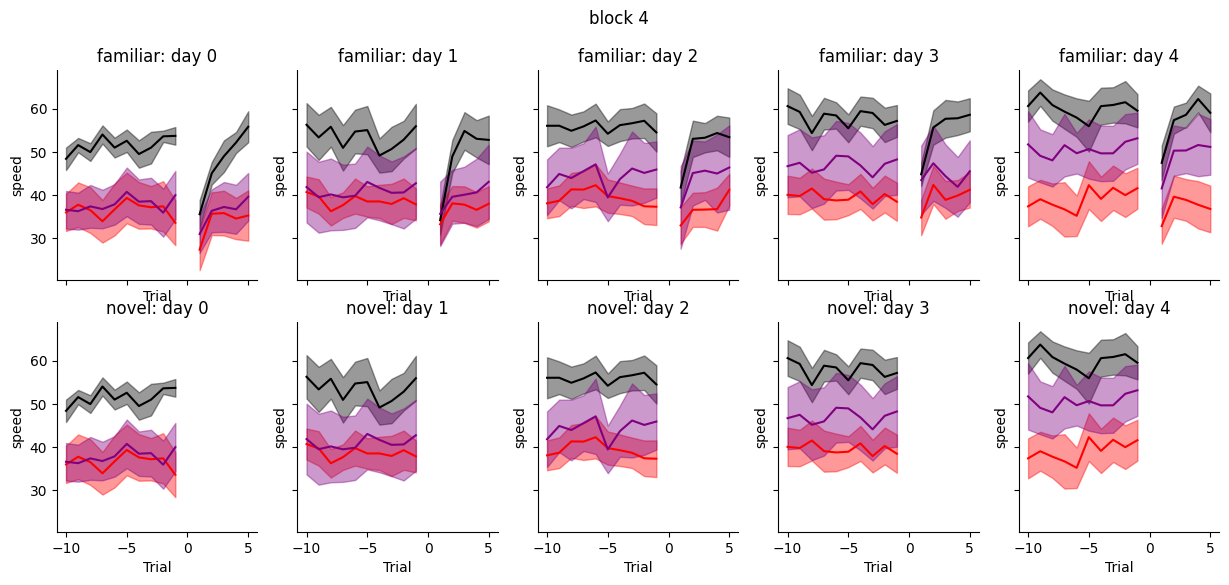

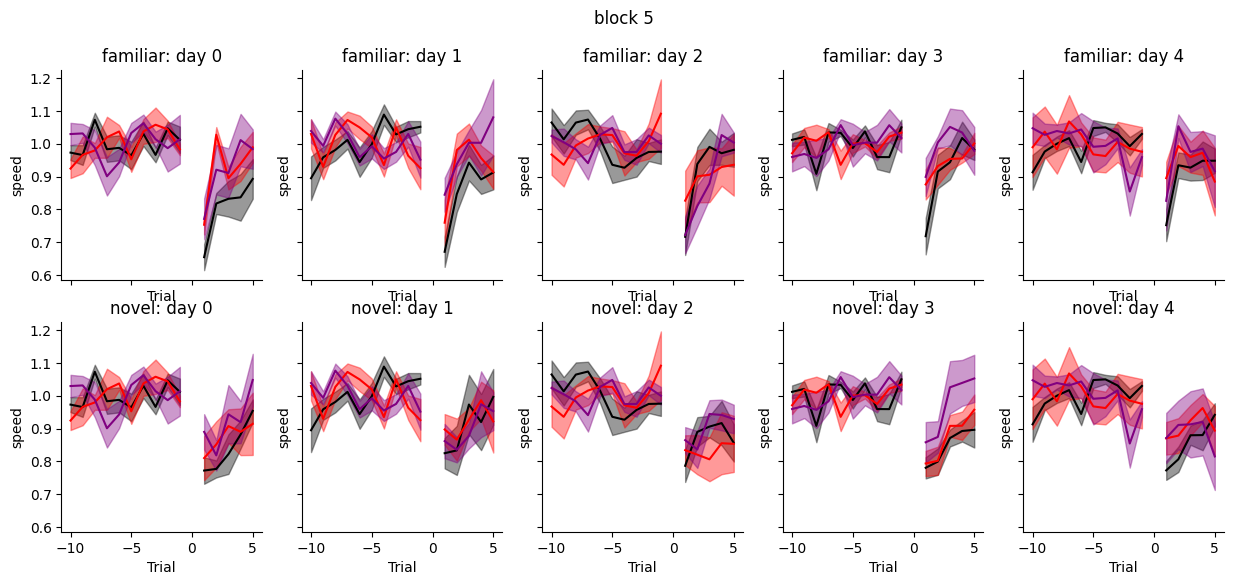

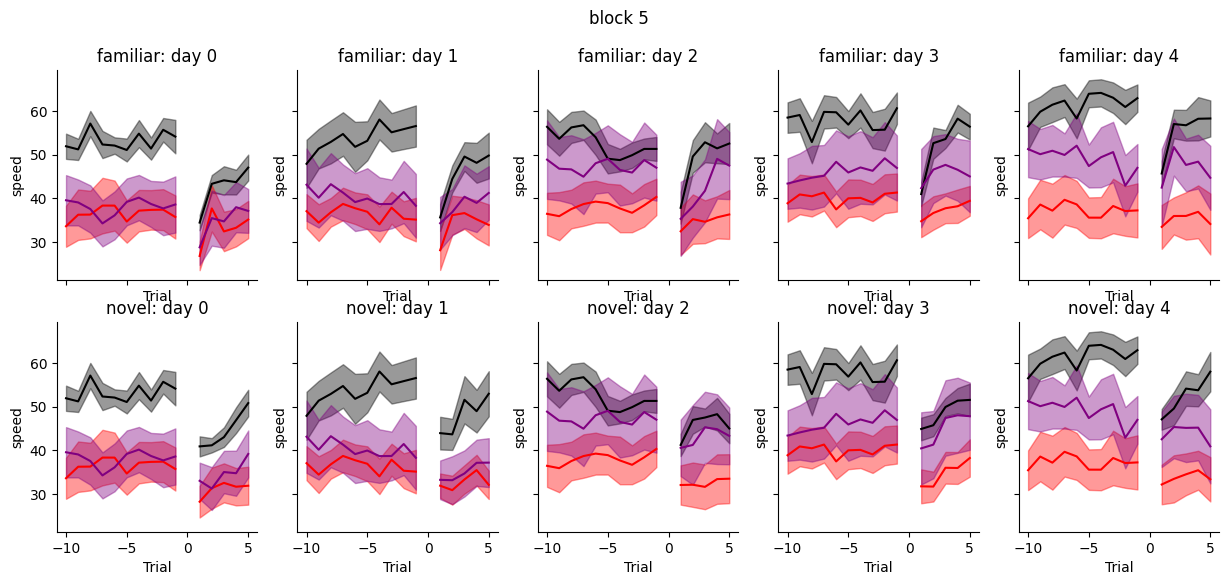

In [16]:
df_list = []
for block in (1,2,3,4,5):
    block_rate = stx.novel_activity_rate.BlockTransitionBehavior( block=block)
    fig, ax = plot_block_avg_behavior(block_rate, key='speed', norm = 'population', max_trial=5)
    fig.suptitle(f'block {block}')
    fig.savefig(figdir / f'block{block}_speed_norm.pdf')

    fig, ax = plot_block_avg_behavior(block_rate, key='speed', norm = None, max_trial=5)
    fig.suptitle(f'block {block}')
    fig.savefig(figdir / f'block{block}_speed.pdf')
    _df = block_rate.df
    _df['block'] = block
    df_list.append(_df)
df = pd.concat(df_list, ignore_index=True)

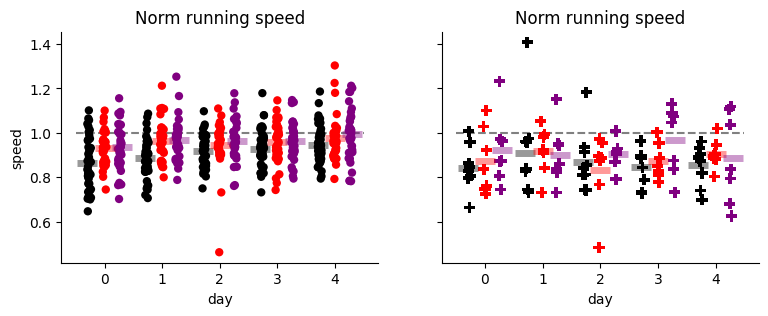

In [17]:
df = df.loc[df['day']<5]
fig,ax = plt.subplots(1,2, figsize=[9,3], sharey = True)
# df = block_rate.df
sns.stripplot(data=df.loc[df['ttype']=='familiar',:],
            x='day',
            y='speed',
            hue='condition', 
            hue_order=('ctrl', 'ko', 'sparse'), 
            palette=['black', 'red', 'purple'],
            dodge=True,
            alpha=1.,s=6,
            ax=ax[0],
            legend=False)

sns.pointplot(data=df.loc[df['ttype']=='familiar',:],
            x='day',
            y='speed',
            errorbar=None,
            estimator=np.mean,
            hue='condition',
            dodge = .6,
            hue_order=('ctrl', 'ko', 'sparse'), 
            palette=['black', 'red', 'purple'],
            ax=ax[0],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,zorder=10,
            )

sns.stripplot(data=df.loc[df['ttype']=='novel',:],
            x='day',
            y='speed',
            hue='condition', 
            hue_order=('ctrl', 'ko', 'sparse'), 
            palette=['black', 'red', 'purple'],
            marker='P', 
            dodge=True,
            alpha= 1., s=8, linewidth=0,
            ax=ax[1],
            legend=False)

sns.pointplot(data=df.loc[df['ttype']=='novel',:],
            x='day',
            y='speed',
            errorbar=None,
            estimator=np.mean,
            hue='condition',
            dodge = .6,
            hue_order=('ctrl', 'ko', 'sparse'), 
            palette=['black', 'red', 'purple'],
            ax=ax[1],
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,zorder=10,
            )


#
for a in ax:
    a.set_title('Norm running speed')
    a.hlines(1,-.5,4.5, color='gray', linestyle='--')
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

fig.savefig(figdir / 'novel_speed_by_day.pdf', bbox_inches='tight')


In [18]:
df_clean = df.dropna()

In [20]:
import statsmodels.formula.api as smf

df_clean['rank_speed'] = df_clean['speed'].rank()
df_clean = df_clean.loc[df_clean['ttype']=='novel']

mdl = smf.mixedlm('rank_speed ~   C(day) * C(condition)', df_clean, groups=df_clean['mouse'])
mdl_result = mdl.fit()

mdl_result.summary()

/tmp/ipykernel_528329/2371434516.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['rank_speed'] = df_clean['speed'].rank()


<class 'statsmodels.iolib.summary2.Summary'>
"""
                      Mixed Linear Model Regression Results
==================================================================================
Model:                      MixedLM         Dependent Variable:         rank_speed
No. Observations:           114             Method:                     REML      
No. Groups:                 23              Scale:                      35971.5726
Min. group size:            4               Log-Likelihood:             -682.3006 
Max. group size:            5               Converged:                  Yes       
Mean group size:            5.0                                                   
----------------------------------------------------------------------------------
                                    Coef.   Std.Err.   z    P>|z|  [0.025   0.975]
----------------------------------------------------------------------------------
Intercept                           173.889   69.874  2.489 0.013   36.938 310.840
C(day)[T.1]                          78.000   89.407  0.872 0.383  -97.235 253.235
C(day)[T.2]                          23.556   89.407  0.263 0.792 -151.680 198.791
C(day)[T.3]                           2.556   89.407  0.029 0.977 -172.680 177.791
C(day)[T.4]                          22.111   89.407  0.247 0.805 -153.124 197.346
C(condition)[T.ko]                   71.825  105.640  0.680 0.497 -135.225 278.876
C(condition)[T.sparse]              116.111  105.640  1.099 0.272  -90.940 323.162
C(day)[T.1]:C(condition)[T.ko]        6.429  135.171  0.048 0.962 -258.502 271.359
C(day)[T.2]:C(condition)[T.ko]      -46.841  135.171 -0.347 0.729 -311.772 218.090
C(day)[T.3]:C(condition)[T.ko]      -29.127  135.171 -0.215 0.829 -294.058 235.804
C(day)[T.4]:C(condition)[T.ko]        8.317  135.171  0.062 0.951 -256.613 273.248
C(day)[T.1]:C(condition)[T.sparse] -111.286  135.171 -0.823 0.410 -376.217 153.645
C(day)[T.2]:C(condition)[T.sparse]  -55.460  138.767 -0.400 0.689 -327.437 216.517
C(day)[T.3]:C(condition)[T.sparse]  109.873  135.171  0.813 0.416 -155.058 374.804
C(day)[T.4]:C(condition)[T.sparse]  -18.968  135.171 -0.140 0.888 -283.899 245.963
Group Var                          7970.190   28.684                              
==================================================================================

"""

In [21]:
mdl_result.wald_test_terms()

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                                       chi2                P>chi2  df constraint
Intercept             [[6.193108607346967]]  0.012824871228948697              1
C(day)               [[0.9877515825139945]]    0.9116475277108099              4
C(condition)         [[1.2570617281451686]]     0.533374825800494              2
C(day):C(condition)    [[4.21992596667269]]    0.8367557256610141              8

In [23]:
pg.mixed_anova(data = df_clean, dv='rank_speed', between='condition', within='day', subject='mouse')

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,condition,299563.220779,2,19,149781.610390,2.112729,0.148422,0.181932,NaN
1,day,35926.090909,4,76,8981.522727,0.256977,0.904543,0.013345,0.865148
2,Interaction,245692.782107,8,76,30711.597763,0.878712,0.538363,0.084665,NaN


In [6]:
# block transition x day matrix
plot_mats = {}
for cond, mice in zip(('ctrl', 'ko', 'sparse'), (ctrl_mice, ko_mice, sparse_mice)):
    mat = np.zeros((5,5, len(mice)))*np.nan
    cond_mask = (df['condition']==cond) * (df['ttype']=='familiar')
    for i, block in enumerate(range(1,6)):
        block_mask = df['block'] == block
        for day in range(5):
            day_mask = df['day'] == day
            for k, mouse in enumerate(mice):

                mask = cond_mask*block_mask*day_mask*(df['mouse']==mouse)
                if mask.sum()>0:
                    mat[i, day, k] = df.loc[mask, 'speed'].values
            #     vals = df.loc[mask,'speed'].values
            # mat[i,day,:vals.shape[0]] = vals
    plot_mats[cond]=mat



# average group norm speeds

# take difference


# make summary plot

/tmp/ipykernel_528329/3087532070.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  mat[i, day, k] = df.loc[mask, 'speed'].values


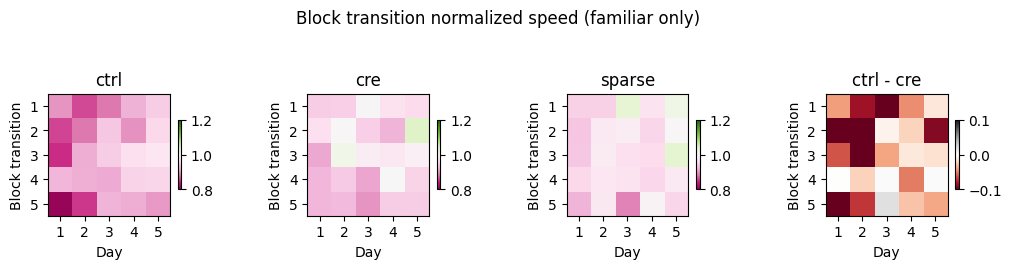

In [7]:
fig, ax =plt.subplots(1,4, figsize=[12,3])
fig.subplots_adjust(wspace=.7)
h = ax[0].imshow(np.nanmean(plot_mats['ctrl'],axis=-1), vmin=.8,vmax=1.2, cmap='PiYG')
ax[0].set_title('ctrl')

plt.colorbar(h, shrink=.3)
h = ax[1].imshow(np.nanmean(plot_mats['ko'], axis=-1), vmin=.8,vmax=1.2, cmap='PiYG')
ax[1].set_title('cre')
plt.colorbar(h, shrink=.3)

h = ax[2].imshow(np.nanmean(plot_mats['sparse'], axis=-1), vmin=.8,vmax=1.2, cmap='PiYG')
plt.colorbar(h, shrink=.3)
ax[2].set_title('sparse')

h = ax[3].imshow(np.nanmean(plot_mats['ctrl'], axis=-1)-np.nanmean(plot_mats['ko'], axis=-1), vmin=-.1, vmax=.1, cmap='RdGy')
plt.colorbar(h, shrink=.3)
ax[3].set_title('ctrl - cre')

for a in ax:
    a.set_xlabel('Day')
    a.set_ylabel('Block transition')
    a.set_xticks([0,1,2,3,4], labels = [1,2,3,4,5])
    a.set_yticks([0,1,2,3,4], labels = [1,2,3,4,5])
fig.suptitle('Block transition normalized speed (familiar only)')
fig.savefig(figdir / "fam_norm_speed_allblocks.pdf")

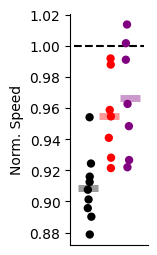

In [8]:
rows = []
for cond, mat in plot_mats.items():
    n_mice = mat.shape[-1]
    for m in range(n_mice):
        rows.append({'condition': cond,
                     'mouse': m,
                     'mu': np.nanmean(mat[:,:,m].ravel()),
                     'plot_x': 0,})
tmp_df = pd.DataFrame(rows)


fig, ax = plt.subplots(figsize=[1,3])
sns.stripplot(data=tmp_df,
            x='plot_x',
            y='mu',
            hue='condition', 
            hue_order=('ctrl', 'ko', 'sparse'), 
            palette=['black', 'red', 'purple'],
            dodge=True,
            alpha=1.,s=6,
            ax=ax,
            legend=False)

sns.pointplot(data=tmp_df,
            x='plot_x',
            y='mu',
            errorbar=None,
            estimator=np.mean,
            hue='condition',
            dodge = .6,
            hue_order=('ctrl', 'ko', 'sparse'), 
            palette=['black', 'red', 'purple'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,zorder=10,
            )


ax.plot([-.5,.5], [1,1], linestyle='--', color='k', zorder=-1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks([])
ax.set_xlabel('')
ax.set_ylabel('Norm. Speed')

fig.savefig(figdir / "fam_norm_speed_summary.pdf")


In [10]:
pg.kruskal(data=tmp_df, dv='mu', between='condition')

,Source,ddof1,H,p-unc
Kruskal,condition,2,12.191856,0.002252


In [11]:
pg.pairwise_tests(data = tmp_df, dv='mu', between='condition', subject='mouse', parametric=False, padjust='holm')

,Contrast,A,B,Paired,Parametric,U-val,alternative,p-unc,p-corr,p-adjust,hedges
0,condition,ctrl,ko,False,False,4.0,two-sided,0.002098,0.006294,holm,-1.776566
1,condition,ctrl,sparse,False,False,4.0,two-sided,0.002098,0.006294,holm,-1.875685
2,condition,ko,sparse,False,False,19.0,two-sided,0.534965,0.534965,holm,-0.341396
